In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import plotly.express as px
import matplotlib.patheffects as pe

# Загрузка датафрейма
path = kagglehub.dataset_download("patriciacarvalhom/worldwide-mobile-app-user-behavior-dataset")

Using Colab cache for faster access to the 'worldwide-mobile-app-user-behavior-dataset' dataset.


# EDA (exploratory data analysis)

In [ ]:
df = pd.read_excel(os.path.join(path, "mobile_app_user_dataset_1.xlsx"))
df.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,ID,StartDate,EndDate,Response Status,Participant Type,Q1_1_TEXT,Q1_2_TEXT,Q1_3_TEXT,Q1_4_TEXT,Q1_5_TEXT,...,Q30_1,Q30_2,Q30_3,Q30_4,Q30_5,Q30_6,Q30_7,Q30_8,Q30_9,Q30_10
0,Unique ID for each participant,StartDate,EndDate,"0=incomplete response, 1=complete response, 2=...","1=ours, 2=panel",Browser Meta Info-Browser,Browser Meta Info-Version,Browser Meta Info-Operating System,Browser Meta Info-Screen Resolution,Browser Meta Info-Flash Version,...,Your personality may influence the types of ap...,Your personality may influence the types of ap...,Your personality may influence the types of ap...,Your personality may influence the types of ap...,Your personality may influence the types of ap...,Your personality may influence the types of ap...,Your personality may influence the types of ap...,Your personality may influence the types of ap...,Your personality may influence the types of ap...,Your personality may influence the types of ap...
1,1,2012-09-26 07:46:07,2012-09-26 07:46:21,2,1,Chrome,21.0.1180.89,WOW64,1280x800,11.3.31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2012-09-26 07:45:19,2012-09-26 07:56:41,1,1,Safari iPhone,6,CPU iPhone OS 6_0 like Mac OS X,320x480,-1,...,6,3,7,2,6,3,4,3,4,4
3,3,2012-09-26 07:45:35,2012-09-26 08:01:56,1,1,Safari,6,CPU OS 6_0 like Mac OS X,768x1024,-1,...,4,4,5,2,3,3,5,3,5,3
4,4,2012-09-26 16:58:29,2012-09-26 17:05:50,1,1,Firefox,15.0.1,Intel Mac OS X 10.6,1920x1200,11.4.402,...,4,3,6,3,5,5,5,2,5,3


In [ ]:
# размер датасета
df.shape

(10209, 161)

In [ ]:
# типы данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10209 entries, 0 to 10208
Columns: 161 entries, ID to Q30_10
dtypes: object(161)
memory usage: 12.5+ MB


Во второй строке содержатся метаданные о содержании колонок, выведем их чтобы изучить подробнее и уберем из итогового датасета

In [ ]:
column_info = df.iloc[0]
column_info

,0
ID,Unique ID for each participant
StartDate,StartDate
EndDate,EndDate
Response Status,"0=incomplete response, 1=complete response, 2=..."
Participant Type,"1=ours, 2=panel"
...,...
Q30_6,Your personality may influence the types of ap...
Q30_7,Your personality may influence the types of ap...
Q30_8,Your personality may influence the types of ap...
Q30_9,Your personality may influence the types of ap...


In [ ]:
# сохраним метаданные отдельно, чтобы расшифровывать по ним результаты
df_info = column_info.reset_index()
df_info.columns = ['Column', 'Description']
df_info.to_csv("column_info.csv", index=False, encoding="utf-8")

In [ ]:
# удаляем вторую строку с метаданными колонок
df = df.drop(index=0).reset_index(drop=True)

In [ ]:
df = df[df['Response Status'] == 1] # выбираем только завершенные ответы
df = df[df['Q2'] == 1] # только пользователи, которые владеют устройством

In [ ]:
# приводим даты к нужному типу
df['StartDate'] = pd.to_datetime(df['StartDate'])
df['EndDate'] = pd.to_datetime(df['EndDate'])

In [ ]:
df

,ID,StartDate,EndDate,Response Status,Participant Type,Q1_1_TEXT,Q1_2_TEXT,Q1_3_TEXT,Q1_4_TEXT,Q1_5_TEXT,...,Q30_1,Q30_2,Q30_3,Q30_4,Q30_5,Q30_6,Q30_7,Q30_8,Q30_9,Q30_10
1,2,2012-09-26 07:45:19,2012-09-26 07:56:41,1,1,Safari iPhone,6,CPU iPhone OS 6_0 like Mac OS X,320x480,-1,...,6,3,7,2,6,3,4,3,4,4
2,3,2012-09-26 07:45:35,2012-09-26 08:01:56,1,1,Safari,6,CPU OS 6_0 like Mac OS X,768x1024,-1,...,4,4,5,2,3,3,5,3,5,3
3,4,2012-09-26 16:58:29,2012-09-26 17:05:50,1,1,Firefox,15.0.1,Intel Mac OS X 10.6,1920x1200,11.4.402,...,4,3,6,3,5,5,5,2,5,3
4,5,2012-09-27 04:16:04,2012-09-27 04:24:56,1,1,Chrome,22.0.1229.79,Intel Mac OS X 10_7_4,1280x800,11.4.402,...,2,6,4,3,6,5,7,3,5,3
5,6,2012-09-27 08:50:34,2012-09-27 08:56:48,1,1,Chrome,21.0.1180.89,WOW64,1920x1080,11.3.31,...,3,2,6,2,6,4,3,2,5,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10085,10086,2012-11-20 23:53:50,2012-11-21 00:01:11,1,2,MSIE,9,Windows NT 6.1,1366x768,11.1.102.55,...,4,4,3,4,5,4,4,2,4,3
10091,10092,2012-11-21 01:14:03,2012-11-21 01:22:39,1,2,Chrome,22.0.1250.0,Windows NT 5.1,1366x768,11.5.502,...,5,5,5,3,5,5,5,4,5,3
10110,10111,2012-11-22 13:28:43,2012-11-22 13:35:36,1,2,MSIE,9,Windows NT 6.1,1441x810,11.4.402.287,...,6,2,6,1,7,1,3,3,3,4
10111,10112,2012-11-22 14:31:54,2012-11-22 14:40:10,1,2,Safari,4,Android 4.0.4,720x1280,11.1.115,...,7,3,4,6,7,3,5,6,3,2


## Тип устройства и платформа

Изучим колонки с информацией по типу браузера, типу ОС, бренду устройства

In [ ]:
df['Q1_1_TEXT'] = df['Q1_1_TEXT'].str.lower()
df['Q1_1_TEXT'].value_counts()

,count
Q1_1_TEXT,
chrome,1591
msie,1522
firefox,1053
safari,371
opera,90
safari iphone,85
mozilla,14


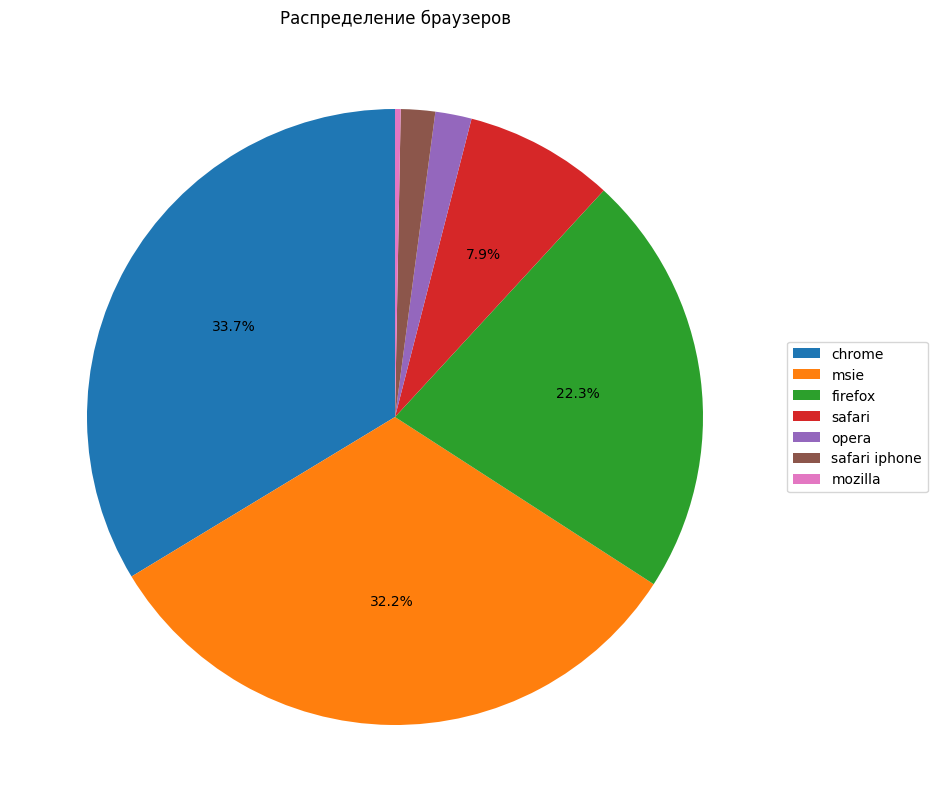

In [ ]:
def autopct_func(pct):
    return f'{pct:.1f}%' if pct > 3 else ''  # показываем только если >3%

plt.figure(figsize=(10, 10))
df['Q1_1_TEXT'].value_counts().plot.pie(autopct=autopct_func,
                                        startangle=90,
                                        labels=None)

plt.legend(df['Q1_1_TEXT'].value_counts().index, loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Распределение браузеров')
plt.ylabel('')

plt.show()


In [ ]:
df['Q1_3_TEXT'] = df['Q1_3_TEXT'].fillna('').str.lower()
df['Q1_3_TEXT'].value_counts()

,count
Q1_3_TEXT,
windows nt 6.1,2356
windows nt 5.1,1306
windows nt 6.0,363
macintosh,208
,98
...,...
cpu iphone os 4_3_5 like mac os x,1
cpu os 3_2_2 like mac os x,1
intel mac os x,1


In [ ]:
def clean_os(os):
    if 'windows' in os:
        return 'Windows'
    elif 'iphone' in os or 'ios' in os or 'cpu iphone os' in os or 'cpu os' in os:
        return 'iOS'
    elif 'mac' in os or 'macintosh' in os:
        return 'macOS'
    elif 'android' in os:
        return 'Android'
    else:
        return 'Other'

df['os'] = df['Q1_3_TEXT'].apply(clean_os)
df['os'].value_counts()

,count
os,
Windows,4060
Other,267
macOS,231
Android,179
iOS,87


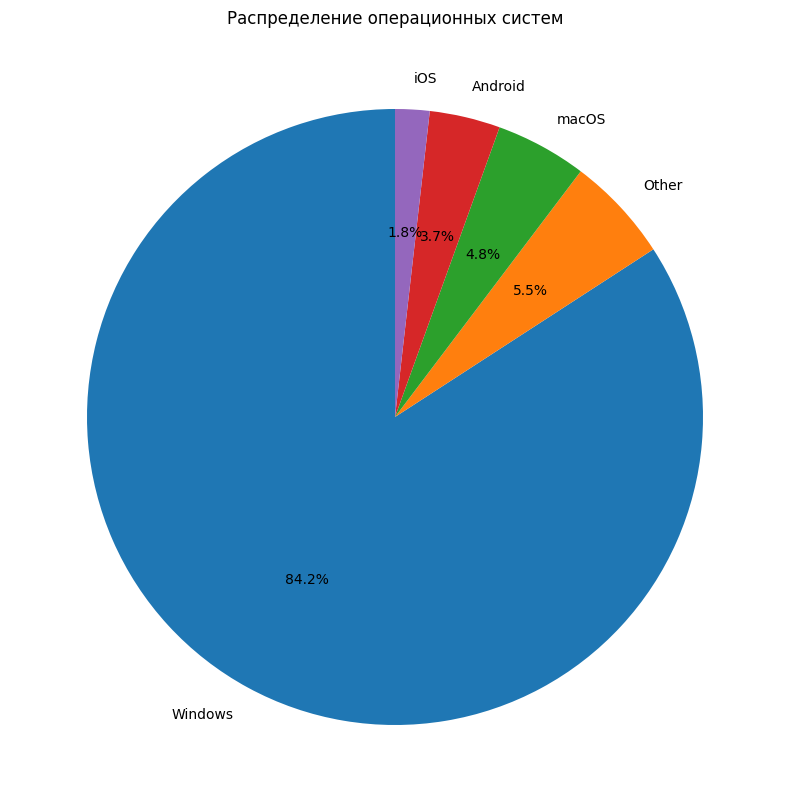

In [ ]:
plt.figure(figsize=(10, 10))
plt.pie(df['os'].value_counts(),
        labels=df['os'].value_counts().index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Распределение операционных систем')
plt.show()

In [ ]:
df['brand'] = df['Q3_1_TEXT'].fillna('').str.lower()
df['brand'] = df['brand'].str.replace(' ', '')
df['brand'].value_counts()

,count
brand,
samsung,995
apple,695
nokia,657
htc,245
blackberry,238
...,...
パンテック,1
galapagos,1
win,1


In [ ]:
def unify_brand(brand):
    if brand in ['apple', 'iphone', '苹果', 'ipad','appleinc.','애플','appleiphone']:
        return 'apple'
    elif brand in ['samsung', '三星','samsing', 'samsunge','삼성','самсунг', 'samsumg','sansung','스카이','sumsung','samsug']:
        return 'samsung'
    elif brand in ['нокиа', '诺基亚','нокия']:
        return 'nokia'
    elif brand in ['htc', 'htc','hct']:  # если есть разные варианты
        return 'htc'
    elif brand in ['シャープ']:
        return 'sharp'
    elif brand in ['blackbeery']:
        return 'blackberry'
    elif brand in ['sonyericson']:
        return 'sonyericsson'
    elif brand in ['华为']:
        return 'huawei'
    elif brand in ['富士通']:
        return 'fujitsu'
    elif brand in ['中兴']:
        return 'zte'
    else:
        return brand

df['brand'] = df['brand'].apply(unify_brand)
top10 = df['brand'].value_counts().head(10)
top10

,count
brand,
samsung,1308
apple,958
nokia,798
htc,246
blackberry,239
lg,223
motorola,123
sonyericsson,98
sony,54


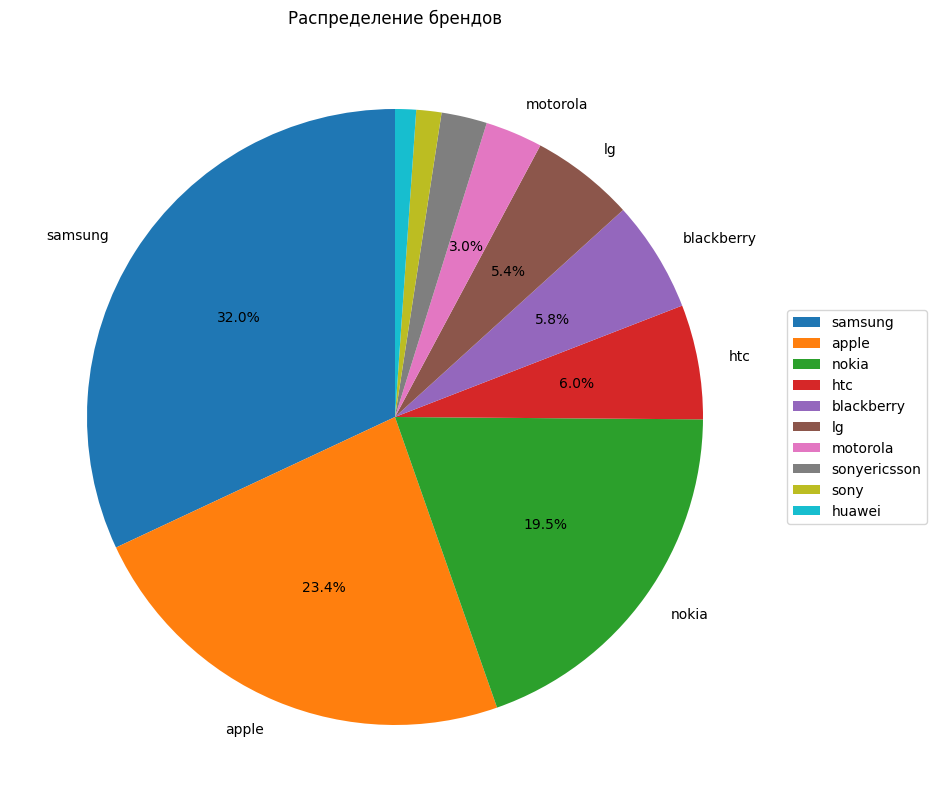

In [ ]:
labels = [label if (count/top10.sum()*100) > 3 else ''
          for label, count in zip(top10.index, top10)]

plt.figure(figsize=(10, 10))
plt.pie(top10,
        autopct=autopct_func,
        labels=labels,
        startangle=90)

plt.legend(top10.index, loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Распределение брендов')
plt.show()

In [ ]:
app_store_mapping = {
    1: 'Apple iOS App Store',
    2: 'Blackberry App World',
    3: 'Google Play / Android Market',
    4: 'Nokia Ovi Store',
    5: 'Samsung Application Store',
    6: 'Windows Phone Marketplace',
    7: 'None - cannot run apps',
    8: "I don't know",
    9: 'Other',
    10: "I don't use apps"
}

df['app_store_name'] = df['Q4'].map(app_store_mapping)
df['app_store_name'].value_counts()

,count
app_store_name,
Google Play / Android Market,1863
Apple iOS App Store,1048
Nokia Ovi Store,709
Samsung Application Store,632
Blackberry App World,288
Windows Phone Marketplace,137
Other,126
I don't know,21


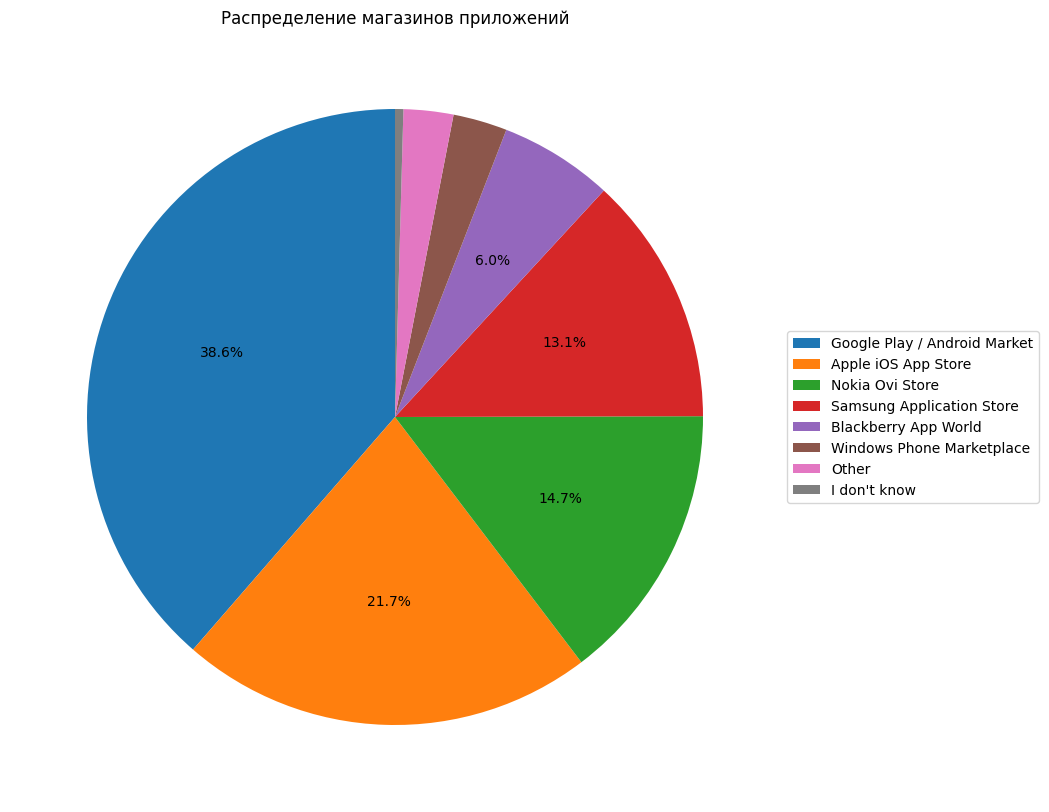

In [ ]:
plt.figure(figsize=(10, 10))
plt.pie(df['app_store_name'].value_counts(),
        autopct=autopct_func,
        startangle=90)

plt.legend(df['app_store_name'].value_counts().index, loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('Распределение магазинов приложений')
plt.show()

## Поведение пользователей

### Частота посещения магазина

In [ ]:
frequency_mapping = {
    1: 'Никогда',
    2: 'Реже чем раз в месяц',
    3: 'Раз в месяц',
    4: 'Чаще раза в месяц',
    5: 'Раз в неделю',
    6: 'Чаще раза в неделю',
    7: 'Раз в день',
    8: 'Несколько раз в день',
    9: 'Другое'}

df['Q5_category'] = df['Q5'].map(frequency_mapping)
df['Q5_category'].value_counts()

,count
Q5_category,
Чаще раза в неделю,915
Реже чем раз в месяц,854
Раз в неделю,601
Чаще раза в месяц,580
Раз в месяц,580
Раз в день,482
Никогда,428
Несколько раз в день,362
Другое,22


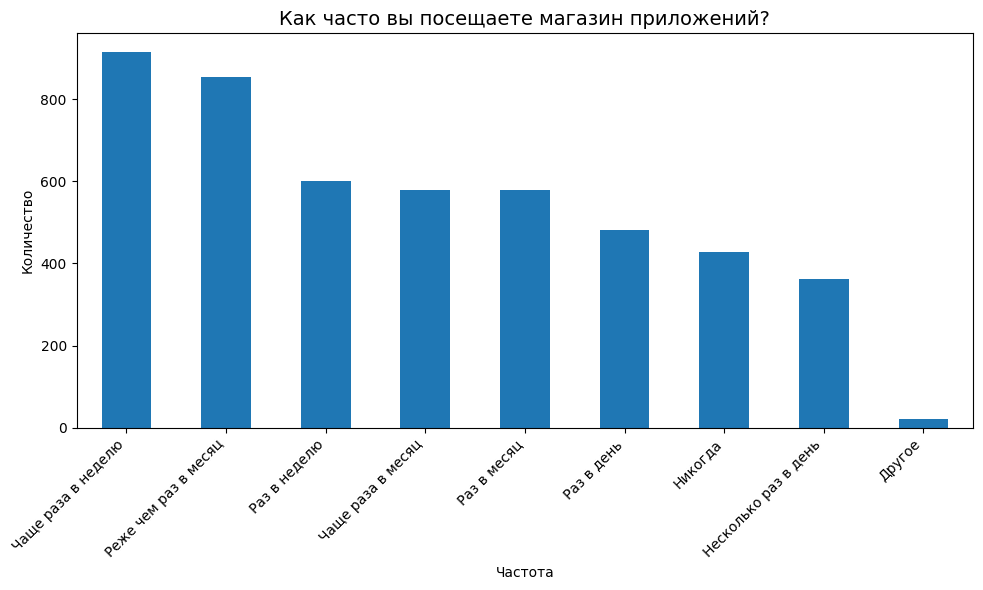

In [ ]:
plt.figure(figsize=(10, 6))
df['Q5_category'].value_counts().plot(kind='bar')
plt.title('Как часто вы посещаете магазин приложений?', fontsize=14)
plt.xlabel('Частота')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Среднее количество загруженных приложений в месяц

In [ ]:
apps_avg_mapping = {1: 0,
                    2: 3,
                    3: 8,
                    4: 15,
                    5: 25,
                    6: 35}

df['apps_avg'] = df['Q6'].map(apps_avg_mapping)

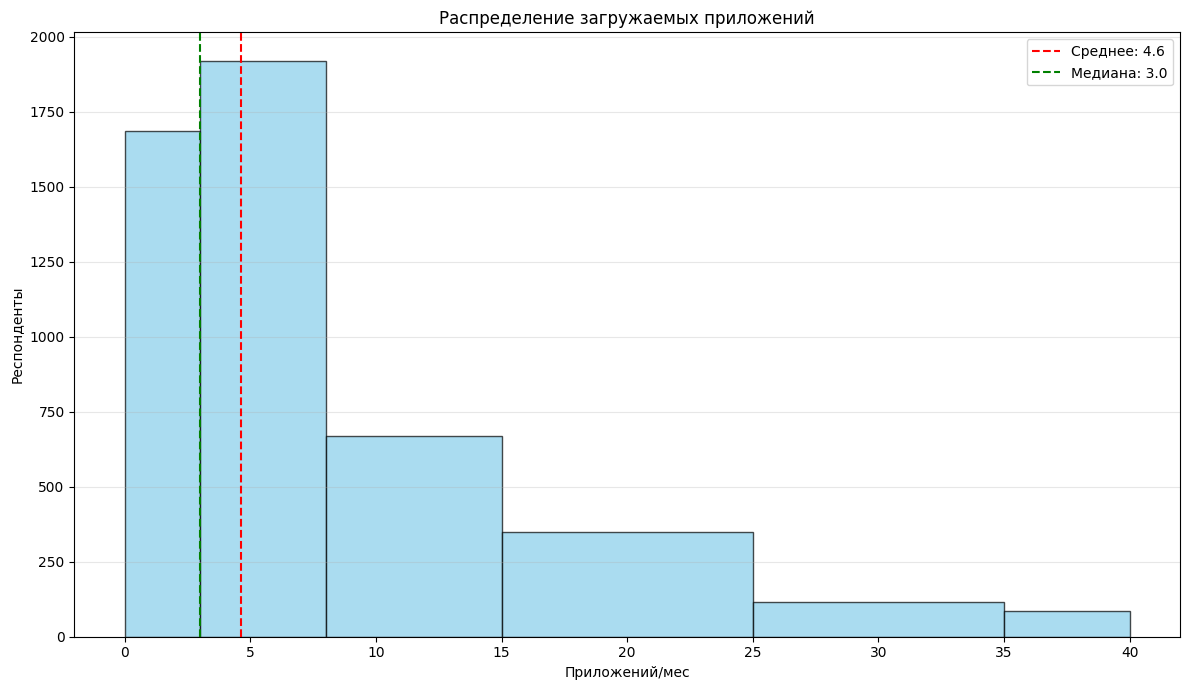

In [ ]:
plt.figure(figsize=(12, 7))
plt.hist(df['apps_avg'].dropna(), bins=[0, 3, 8, 15, 25, 35, 40], edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(df['apps_avg'].mean(), color='red', linestyle='--', label=f'Среднее: {df["apps_avg"].mean():.1f}')
plt.axvline(df['apps_avg'].median(), color='green', linestyle='--', label=f'Медиана: {df["apps_avg"].median():.1f}')
plt.title('Распределение загружаемых приложений')
plt.xlabel('Приложений/мес')
plt.ylabel('Респонденты')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Когда человек ищет приложения и как находит

In [ ]:
q7 = {  'Q7_1': 'Когда чувствую депрессию',
        'Q7_2': 'Когда нужно выполнить задачу',
        'Q7_3': 'Когда скучно',
        'Q7_4': 'Когда хочу развлечься',
        'Q7_5': 'Когда нужно что-то узнать',
        'Q7_6': 'Другое'}

q8 = {  'Q8_1': 'Сравниваю несколько приложений',
        'Q8_2': 'Скачиваю первое попавшееся',
        'Q8_3': 'Ищу на главной странице',
        'Q8_4': 'Смотрю топ загрузок',
        'Q8_5': 'Случайный просмотр',
        'Q8_7': 'Поиск по ключевым словам',
        'Q8_8': 'Посещаю сайты с обзорами',
        'Q8_9': 'Использую поисковики (Google)',
        'Q8_10': 'Другое'}

q7_counts = {label: df[col].sum() for col, label in q7.items()}
q8_counts = {label: df[col].sum() for col, label in q8.items()}

q7_data = pd.Series(q7_counts).sort_values(ascending=True)
q8_data = pd.Series(q8_counts).sort_values(ascending=True)

total_respondents = len(df)

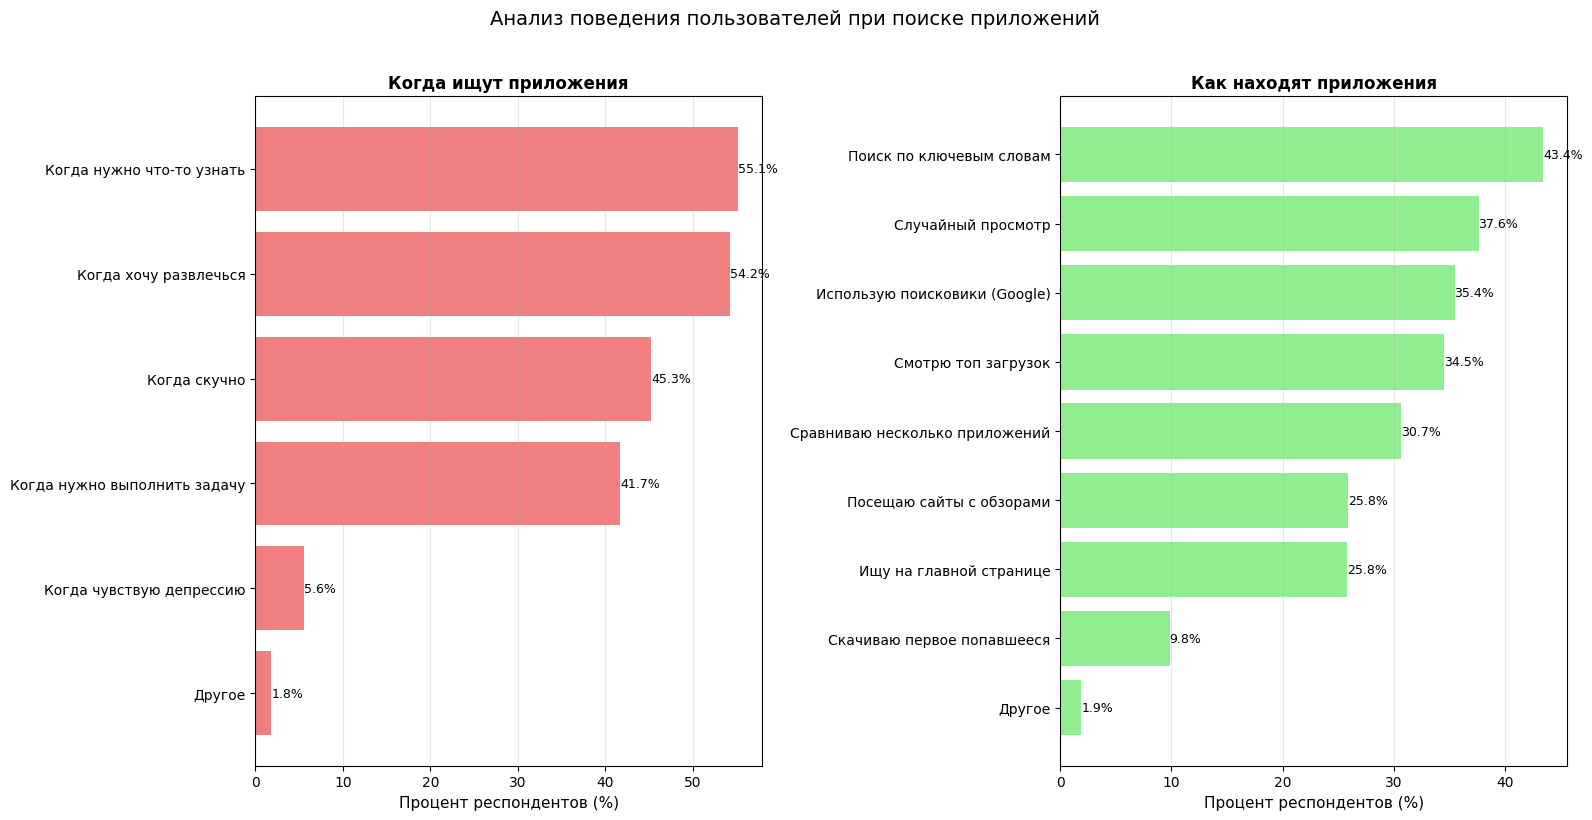

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Q7 - Когда ищут приложения
q7_percentages = (q7_data / total_respondents * 100).sort_values()
bars1 = ax1.barh(q7_percentages.index, q7_percentages.values, color='lightcoral')
ax1.set_xlabel('Процент респондентов (%)', fontsize=11)
ax1.set_title('Когда ищут приложения', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for bar, pct in zip(bars1, q7_percentages.values):
    ax1.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', ha='left', va='center', fontsize=9)

# Q8 - Как находят приложения
q8_percentages = (q8_data / total_respondents * 100).sort_values()
bars2 = ax2.barh(q8_percentages.index, q8_percentages.values, color='lightgreen')
ax2.set_xlabel('Процент респондентов (%)', fontsize=11)
ax2.set_title('Как находят приложения', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for bar, pct in zip(bars2, q8_percentages.values):
    ax2.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', ha='left', va='center', fontsize=9)

plt.suptitle('Анализ поведения пользователей при поиске приложений', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Что учитывают при выборе и почему скачивают

In [ ]:
q9_mapping = {  'Q9_1': 'Отзывы',
                'Q9_2': 'Название',
                'Q9_3': 'Кол-во загрузок',
                'Q9_4': 'Иконка',
                'Q9_5': 'Описание',
                'Q9_6': 'Функции',
                'Q9_7': 'Кол-во оценок',
                'Q9_8': 'Цена',
                'Q9_9': 'Рейтинг',
                'Q9_10': 'Размер',
                'Q9_11': 'Скриншоты',
                'Q9_12': 'Разработчик',
                'Q9_13': 'Другое'}

q10_mapping = { 'Q10_1': 'Общение с друзьями',
                'Q10_2': 'Общение с незнакомцами',
                'Q10_3': 'Выполнить задачу',
                'Q10_4': 'Реклама в магазине',
                'Q10_5': 'Топ загрузок',
                'Q10_6': 'Реклама в приложениях',
                'Q10_7': 'Развлечение',
                'Q10_8': 'Любопытство',
                'Q10_9': 'Импульсивная покупка',
                'Q10_10': 'Известные бренды/звезды',
                'Q10_11': 'Упоминание в СМИ',
                'Q10_12': 'Расширение сайта',
                'Q10_13': 'Рекомендация друзей',
                'Q10_14': 'Для кого-то другого',
                'Q10_15': 'Другое'}

# Подсчитываем количество для Q9
q9_counts = pd.Series({ru_name: df[col].sum()
                       for col, ru_name in q9_mapping.items()
                       if col in df.columns})

# Подсчитываем количество для Q10
q10_counts = pd.Series({ru_name: df[col].sum()
                        for col, ru_name in q10_mapping.items()
                        if col in df.columns})

# Сортируем по убыванию
q9_counts = q9_counts.sort_values(ascending=True)
q10_counts = q10_counts.sort_values(ascending=True)

print("Топ-5 факторов выбора приложений:")
print(q9_counts.tail(5))
print("\nТоп-5 причин скачивания приложений:")
print(q10_counts.tail(5))

Топ-5 факторов выбора приложений:
Рейтинг     2233
Отзывы      2321
Описание    2362
Функции     2376
Цена        2755
dtype: int64

Топ-5 причин скачивания приложений:
Общение с друзьями     1420
Любопытство            1711
Рекомендация друзей    1753
Выполнить задачу       2457
Развлечение            2801
dtype: int64


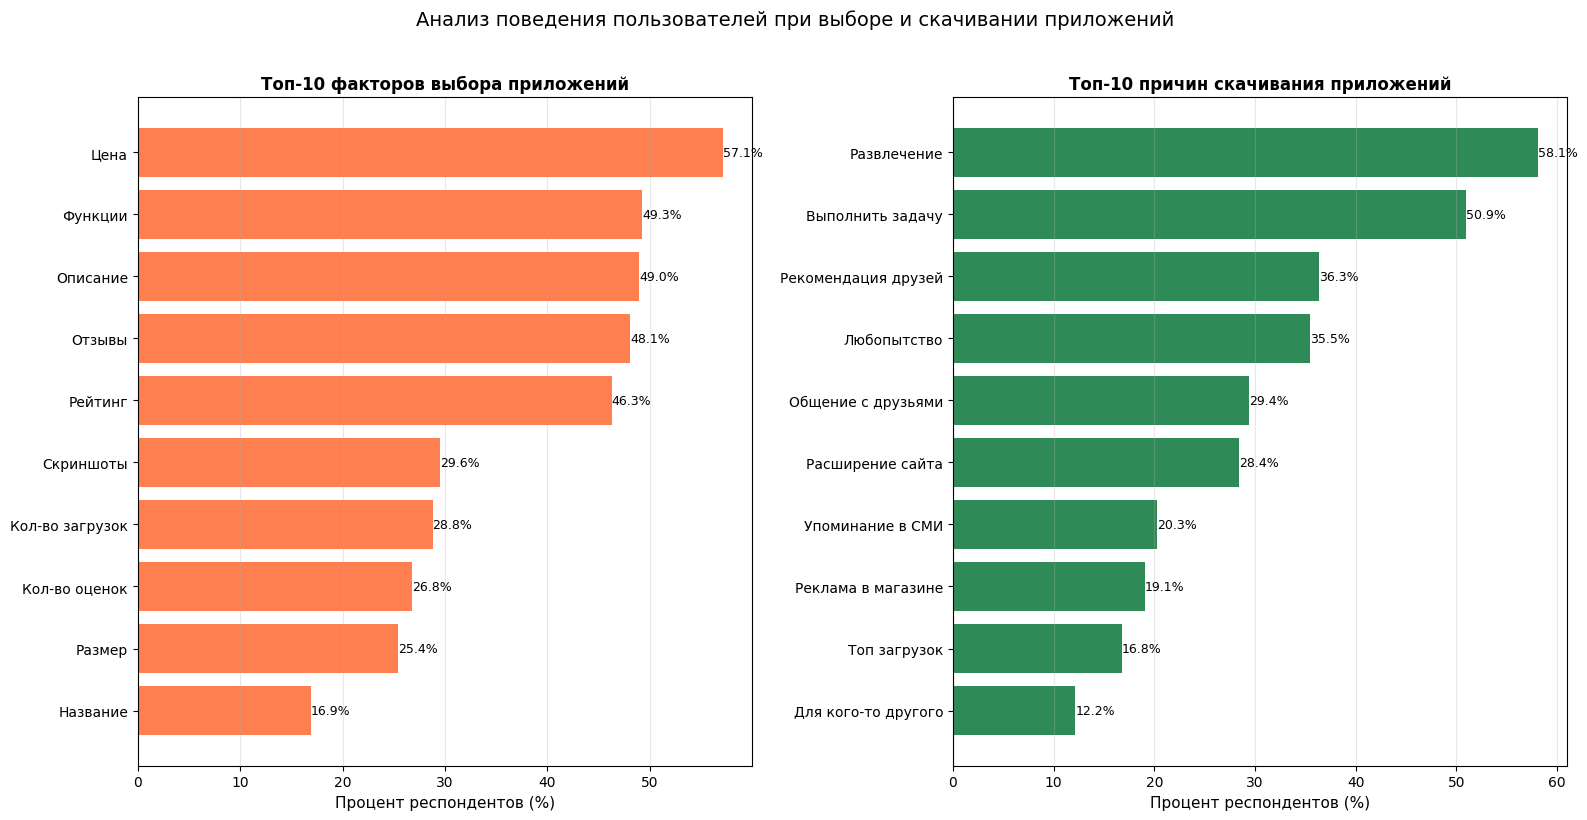

In [ ]:
q9_counts = pd.Series({ru_name: df[col].sum()
                       for col, ru_name in q9_mapping.items()
                       if col in df.columns})
q10_counts = pd.Series({ru_name: df[col].sum()
                        for col, ru_name in q10_mapping.items()
                        if col in df.columns})

q9_percentages = q9_counts / total_respondents * 100
q10_percentages = q10_counts / total_respondents * 100



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Q9 - Топ-10 факторов выбора
q9_top10 = q9_percentages.sort_values().tail(10)
bars1 = ax1.barh(q9_top10.index, q9_top10.values, color='coral')
ax1.set_xlabel('Процент респондентов (%)', fontsize=11)
ax1.set_title('Топ-10 факторов выбора приложений', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

for bar, pct in zip(bars1, q9_top10.values):
    ax1.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', ha='left', va='center', fontsize=9)

# Q10 - Топ-10 причин скачивания
q10_top10 = q10_percentages.sort_values().tail(10)
bars2 = ax2.barh(q10_top10.index, q10_top10.values, color='seagreen')
ax2.set_xlabel('Процент респондентов (%)', fontsize=11)
ax2.set_title('Топ-10 причин скачивания приложений', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for bar, pct in zip(bars2, q10_top10.values):
    ax2.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', ha='left', va='center', fontsize=9)

plt.suptitle('Анализ поведения пользователей при выборе и скачивании приложений', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Про деньги

In [ ]:
q11_mapping = {
    'Q11_1': 'Не плачу за приложения',
    'Q11_2': 'Убрать рекламу',
    'Q11_3': 'Скидка/распродажа',
    'Q11_4': 'Подписка на бесплатный контент',
    'Q11_5': 'Дополнительные функции (freemium)',
    'Q11_6': 'Нет бесплатного аналога',
    'Q11_7': 'Доп. функции платного приложения',
    'Q11_8': 'Подписка на платный контент',
    'Q11_9': 'Платное = лучшее качество',
    'Q11_10': 'Другое',
    'Q11_11': 'Платное = лучше качество',
    'Q11_12': 'Платное = больше функций'}

In [ ]:
# Подсчитываем количество для Q11
q11_counts = pd.Series({ru_name: df[col].sum()
                        for col, ru_name in q11_mapping.items()
                        if col in df.columns})

# Сортируем по убыванию
q11_counts = q11_counts.sort_values(ascending=True)

# Общее количество респондентов
total_respondents = len(df)

# Проценты
q11_percentages = q11_counts / total_respondents * 100

print("Статистика трат на приложения:")
print(f"Всего респондентов: {total_respondents}")
print(f"\nТоп-5 причин траты денег:")
print(q11_counts.tail(5))

Статистика трат на приложения:
Всего респондентов: 4824

Топ-5 причин траты денег:
Скидка/распродажа                     671
Дополнительные функции (freemium)     722
Доп. функции платного приложения      839
Нет бесплатного аналога               937
Не плачу за приложения               2727
dtype: int64


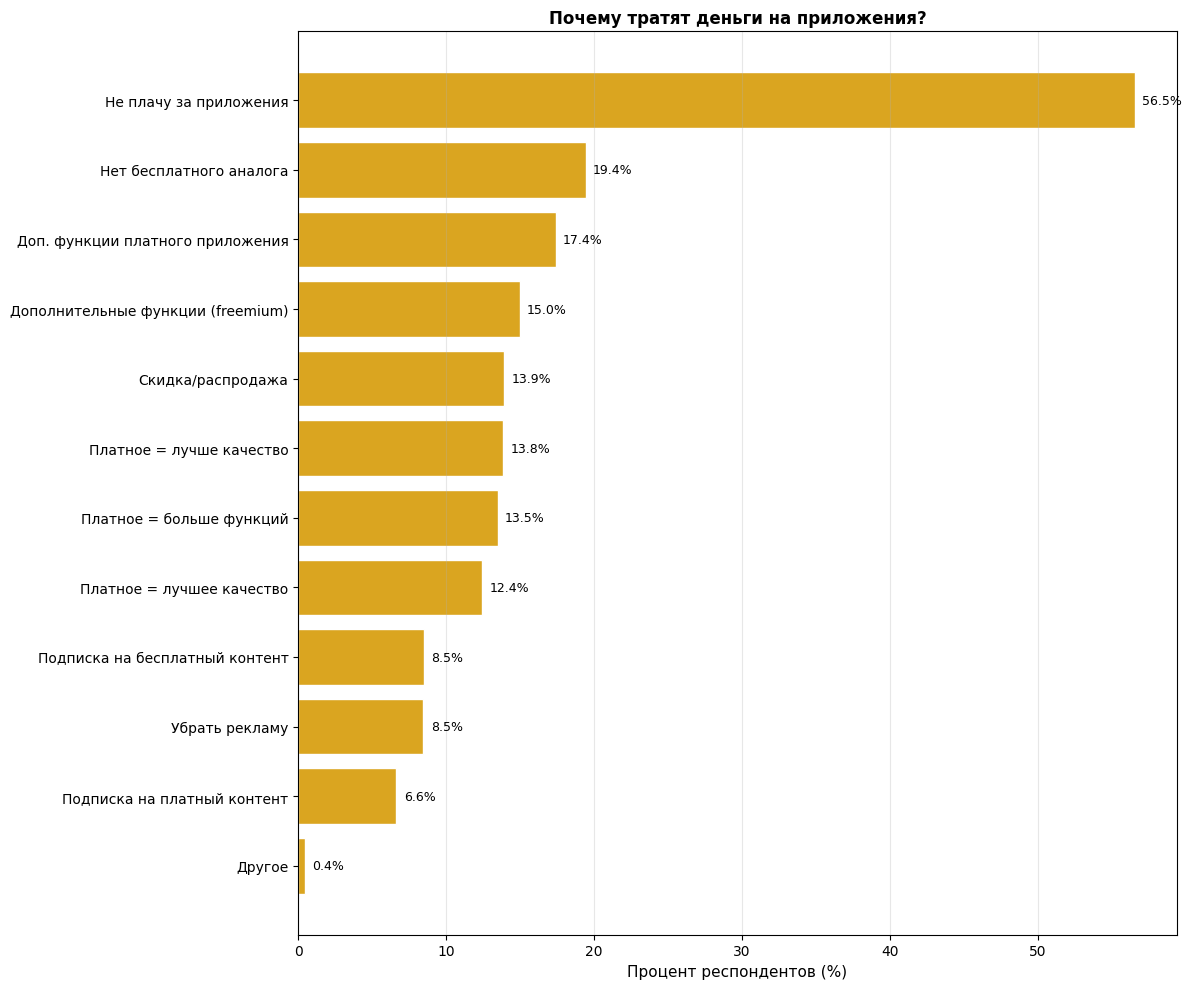

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Q11 - Почему тратят деньги на приложения
q11_percentages_sorted = q11_percentages.sort_values()
bars = ax.barh(q11_percentages_sorted.index, q11_percentages_sorted.values, color='goldenrod', edgecolor='white', linewidth=1)
ax.set_xlabel('Процент респондентов (%)', fontsize=11)
ax.set_title('Почему тратят деньги на приложения?', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for bar, pct in zip(bars, q11_percentages_sorted.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
df['max_spent'] = pd.to_numeric(df['Q12.1_1_TEXT'], errors='coerce')

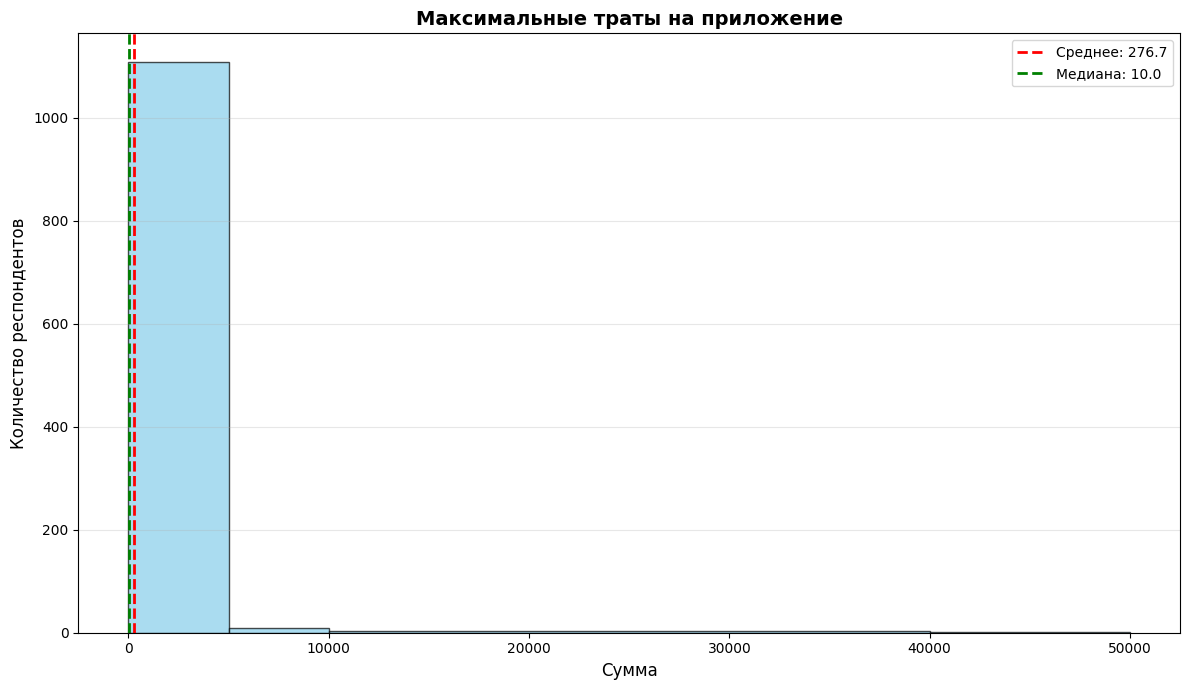

In [ ]:
plt.figure(figsize=(12, 7))
plt.hist(df['max_spent'].dropna(), bins=[0, 5000, 10000, 40000,50000], edgecolor='black', alpha=0.7, color='skyblue')
plt.axvline(df['max_spent'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Среднее: {df['max_spent'].mean():.1f}')
plt.axvline(df['max_spent'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Медиана: {df['max_spent'].median():.1f}')
plt.title('Максимальные траты на приложение', fontsize=14, fontweight='bold')
plt.xlabel('Сумма', fontsize=12)
plt.ylabel('Количество респондентов', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df['max_spent_app'] = df['Q12.1_2_TEXT'].str.lower()
df['max_spent_app'] = df['max_spent_app'].str.replace(' ', '')
df['max_spent_app'].value_counts()

,count
max_spent_app,
angrybirds,54
whatsapp,41
愤怒的小鸟,19
nonricordo,19
can'tremember,16
...,...
咕嘟运动,1
"printcentral,quickottice,istethoscope,adobe,simplyyoga,djay,piano.",1
"gosmsprorainbowtheme,otherthemes",1


In [ ]:
def unify_app(app):
    if app in ['愤怒的小鸟','angrybird','angrybirds']:
        return 'angrybirds'
    elif app in ["can'tremember", 'непомню','notsure','none',"don'tremember",'?','なし','없음','无']:
        return '-'
    elif app in ['whats app','watsapp']:
        return 'whatsapp'
    elif app in ['norecuerdo','nolorecuerdo','nomeacuerdo','nãolembro','nose']:
        return 'nonricordo'
    elif app in ['高德导航','导航','maps','navigation','navigon']:
        return 'gps'
    else:
        return app

df['max_spent_app'] = df['max_spent_app'].apply(unify_app)
top_apps = df['max_spent_app'].value_counts().head(30)

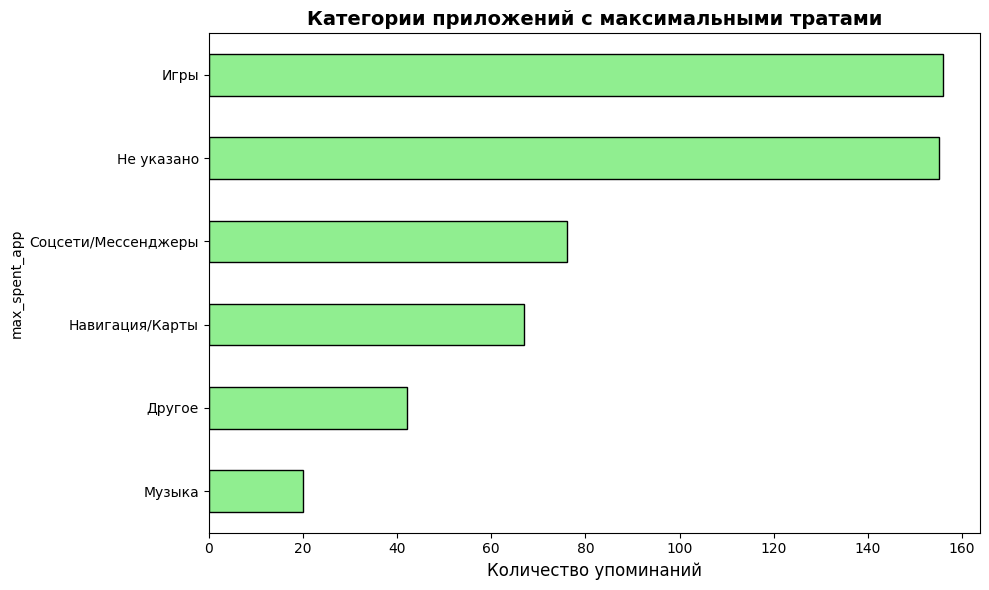

Распределение по категориям:
Музыка: 20 (3.9%)
Другое: 42 (8.1%)
Навигация/Карты: 67 (13.0%)
Соцсети/Мессенджеры: 76 (14.7%)
Не указано: 155 (30.0%)
Игры: 156 (30.2%)


In [ ]:
# Группировка по категориям
categories = {
    'Игры': ['angrybirds', 'games', '植物大战僵尸', 'fruitninja', 'tetris',
             'drawsomething', 'Need for Speed', 'scrabble', 'game', '游戏', 'игры','植物大战僵尸','极品飞车'],

    'Соцсети/Мессенджеры': ['whatsapp', 'facebook', 'qq', 'skype'],

    'Навигация/Карты': ['gps', 'navigation', 'maps', 'tomtom', '高德导航', '凯立德', '导航'],

    'Музыка': ['poweramp', 'shazam', 'musica','garageband' ],

    'Другое': ['pages', '同花顺', 'geocaching','camerazoomfx','snapseed','大智慧','同花顺','swiftkey3','google','itunes','антивирус'],

    'Не указано': ['незнаю', 'нет', 'неизвестно','-','nonricordo']}

category_mapping = {}
for category, apps in categories.items():
    for app in apps:
        category_mapping[app] = category

# Группируем
apps_by_category = top_apps.groupby(lambda x: category_mapping.get(x, 'Другое')).sum()
apps_by_category = apps_by_category.sort_values()

plt.figure(figsize=(10, 6))
apps_by_category.plot(kind='barh', color='lightgreen', edgecolor='black')
plt.title('Категории приложений с максимальными тратами', fontsize=14, fontweight='bold')
plt.xlabel('Количество упоминаний', fontsize=12)
plt.tight_layout()
plt.show()

print("Распределение по категориям:")
for cat, count in apps_by_category.items():
    pct = (count / apps_by_category.sum()) * 100
    print(f"{cat}: {count} ({pct:.1f}%)")

In [ ]:
df['Q12.1_3_TEXT'].value_counts()

,count
Q12.1_3_TEXT,
朋友推荐,45
导航,41
娱乐,31
好玩,20
entertainment,18
...,...
興味関心,1
ナシ,1
好きなアーティストの壁紙がダウンロードできるから,1


In [ ]:
def unify_comms(comm):
    if comm in ['朋友推荐','friend','Friend','empfehlung','聊天']:
        return 'рекомендация'
    elif comm in ['导航','gps','为了导航','GPS']:
        return 'навигация'
    elif comm in ['娱乐','好玩','entertainment','for fun','Entertainment','fun','for entertainment',
                  '游戏','玩游戏','I like the game','For fun','玩','para entretenerme','для развлечения']:
        return 'развлечения'
    elif comm in ['高德导航','导航','maps','navigation','navigon']:
        return 'gps'
    elif comm in ['0','无',0,'none','no']:
        return '-'
    else:
        return comm

df['why_downloaded'] = df['Q12.1_3_TEXT'].apply(unify_comms)

In [ ]:
df['why_downloaded'].value_counts().head(5)

,count
why_downloaded,
развлечения,129
рекомендация,61
навигация,57
-,38
для себя,5


In [ ]:
df['Q12.2'].value_counts()

,count
Q12.2,
0,226
10,111
5,104
50,89
100,68
...,...
"0,5 euro",1
"1,50",1
Dont no,1


In [ ]:

# Функция для определения валюты
def detect_currency(text):
    if pd.isna(text):
        return None
    text = str(text).lower()

    # Определяем валюту по символам или словам
    if '$' in text or 'usd' in text or 'dollar' in text:
        return 'USD'
    elif '€' in text or 'eur' in text or 'euro' in text:
        return 'EUR'
    elif '£' in text or 'gbp' in text or 'pound' in text:
        return 'GBP'
    elif '¥' in text or 'jpy' in text or 'yen' in text:
        return 'JPY'
    elif '₽' in text or 'rub' in text or 'руб' in text:
        return 'RUB'
    elif '₩' in text or 'krw' in text or 'won' in text:
        return 'KRW'
    elif '元' in text or 'rmb' in text or 'cny' in text:
        return 'CNY'
    else:
        return 'UNKNOWN'

# Функция для извлечения числа
def extract_number(text):
    if pd.isna(text):
        return None
    # Ищем числа (включая десятичные)
    numbers = re.findall(r'(\d+[\.,]?\d*)', str(text))
    if numbers:
        # Заменяем запятую на точку
        num = numbers[0].replace(',', '.')
        return float(num)
    return None

# Определяем валюту и извлекаем сумму
df['currency'] = df['Q12.2'].apply(detect_currency)
df['amount_raw'] = df['Q12.2'].apply(extract_number)

# Просмотр уникальных валют
print("Валюты в данных:")
print(df['currency'].value_counts())

Валюты в данных:
currency
UNKNOWN    1793
USD         329
EUR         119
CNY          68
RUB          51
GBP          18
JPY           6
KRW           1
Name: count, dtype: int64


In [ ]:
# среднее арифметическое и медиана
mean_by_currency = df[df['currency'] != 'UNKNOWN'].groupby('currency')['amount_raw'].mean().round(2)
median_by_currency = df[df['currency'] != 'UNKNOWN'].groupby('currency')['amount_raw'].median().round(2)

count_by_currency = df[df['currency'] != 'UNKNOWN'].groupby('currency')['amount_raw'].count()
stats_df = pd.DataFrame({
    'Количество': count_by_currency,
    'Среднее': mean_by_currency,
    'Медиана': median_by_currency})

print("=== Статистика по валютам ===\n")
print(stats_df)

=== Статистика по валютам ===

          Количество  Среднее  Медиана
currency                              
CNY               67    43.19    20.00
EUR              113    12.04     3.00
GBP               18     3.72     1.25
JPY                6   564.17   600.00
KRW                1    10.00    10.00
RUB               50   443.50   237.50
USD              327    84.75     5.00


## Оценки приложений

In [ ]:
q13_mapping = {
    'Q13_1': 'Не ставлю оценки',
    'Q13_2': 'Сообщить, что приложение хорошее',
    'Q13_3': 'Кто-то попросил',
    'Q13_4': 'Приложение попросило',
    'Q13_5': 'Сообщить, что приложение плохое',
    'Q13_6': 'Вознаграждение за оценку',
    'Q13_7': 'Другое'}

q13_counts = pd.Series({ru_name: df[col].sum()
                        for col, ru_name in q13_mapping.items()
                        if col in df.columns})
q13_counts = q13_counts.sort_values(ascending=True)
q13_percentages = (q13_counts / total_respondents * 100).sort_values()
q13_counts

,0
Другое,8
Кто-то попросил,267
Вознаграждение за оценку,547
Приложение попросило,740
"Сообщить, что приложение плохое",988
"Сообщить, что приложение хорошее",1629
Не ставлю оценки,2539


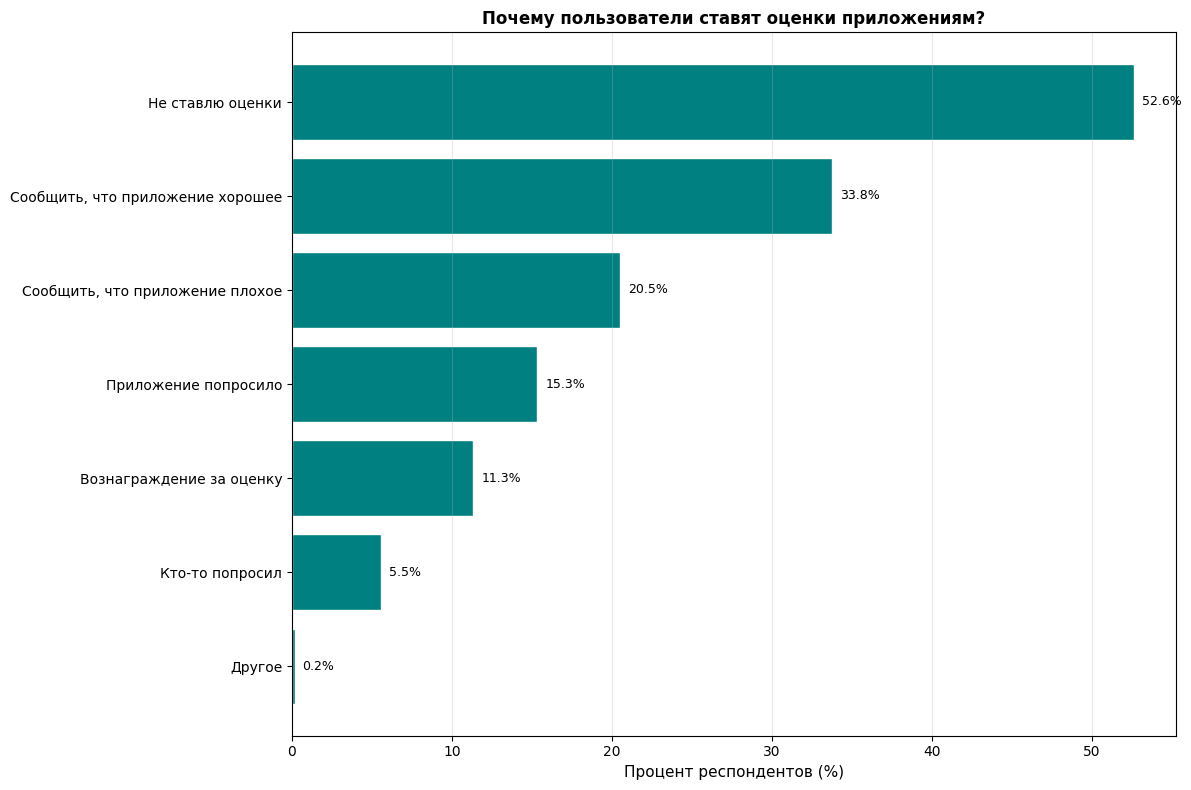

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Q13 - Почему ставят оценки
q13_percentages_sorted = q13_percentages.sort_values()
bars = ax.barh(q13_percentages_sorted.index, q13_percentages_sorted.values,
               color='teal', edgecolor='white', linewidth=1)
ax.set_xlabel('Процент респондентов (%)', fontsize=11)
ax.set_title('Почему пользователи ставят оценки приложениям?', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for bar, pct in zip(bars, q13_percentages_sorted.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Почему перестают пользоваться

In [ ]:
q14_mapping = {
    'Q14_1': 'Вылетает/зависает',
    'Q14_2': 'Нашел лучшее приложение',
    'Q14_3': 'Раздражающая реклама',
    'Q14_4': 'Сложно использовать',
    'Q14_5': 'Друзья/семья перестали использовать',
    'Q14_6': 'Нужно платить за функции',
    'Q14_7': 'Забыл о приложении',
    'Q14_8': 'Не нужны функции',
    'Q14_9': 'Нарушает конфиденциальность',
    'Q14_10': 'Слишком медленное',
    'Q14_11': 'Надоело',
    'Q14_12': 'Не работает',
    'Q14_13': 'Нет нужных функций',
    'Q14_15': 'Больше не нужно',
    'Q14_14': 'Другое'}

q14_counts = pd.Series({ru_name: df[col].sum()
                        for col, ru_name in q14_mapping.items()
                        if col in df.columns})
q14_counts = q14_counts.sort_values(ascending=True)
q14_percentages = (q14_counts / total_respondents * 100).sort_values()
q14_counts

,0
Другое,43
Друзья/семья перестали использовать,373
Забыл о приложении,710
Нарушает конфиденциальность,835
Не нужны функции,1192
Раздражающая реклама,1195
Нужно платить за функции,1212
Сложно использовать,1278
Не работает,1469
Слишком медленное,1627


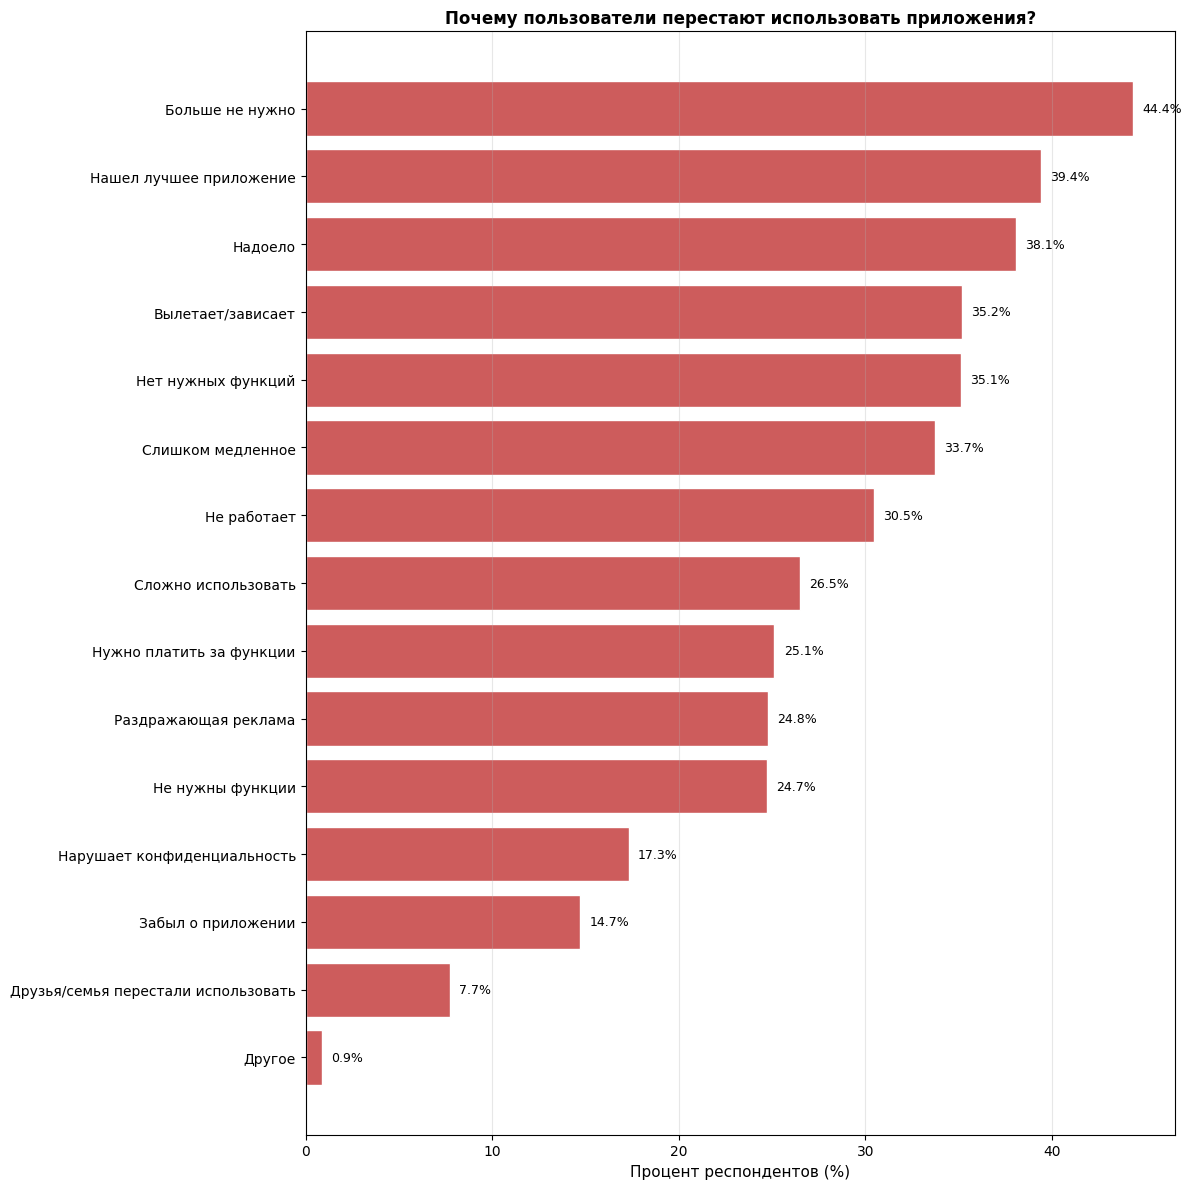

In [ ]:
plt.figure(figsize=(12, 12))
q14_percentages_sorted = q14_percentages.sort_values()
bars = plt.barh(q14_percentages_sorted.index, q14_percentages_sorted.values,
                color='indianred', edgecolor='white', linewidth=1)
plt.xlabel('Процент респондентов (%)', fontsize=11)
plt.title('Почему пользователи перестают использовать приложения?', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for bar, pct in zip(bars, q14_percentages_sorted.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Сегментация по типам приложений

In [ ]:
q15_mapping = {
    'Q15_1': 'Навигация',
    'Q15_2': 'Бизнес',
    'Q15_3': 'Каталоги',
    'Q15_4': 'Путешествия',
    'Q15_5': 'Книги',
    'Q15_6': 'Фото и видео',
    'Q15_7': 'Образ жизни',
    'Q15_8': 'Развлечения',
    'Q15_9': 'Финансы',
    'Q15_10': 'Новости',
    'Q15_11': 'Здоровье и фитнес',
    'Q15_12': 'Игры',
    'Q15_13': 'Еда и напитки',
    'Q15_14': 'Образование',
    'Q15_15': 'Медицина',
    'Q15_16': 'Соцсети',
    'Q15_17': 'Справочники',
    'Q15_18': 'Спорт',
    'Q15_19': 'Утилиты',
    'Q15_20': 'Погода',
    'Q15_21': 'Продуктивность',
    'Q15_22': 'Музыка',
    'Q15_23': 'Другое'}

In [ ]:
q15_counts = pd.Series({ru_name: df[col].sum()
                        for col, ru_name in q15_mapping.items()
                        if col in df.columns})
q15_counts = q15_counts.sort_values(ascending=True)
q15_percentages = (q15_counts / total_respondents * 100).sort_values()
q15_counts.tail(10)

,0
Новости,1358
Книги,1447
Развлечения,1489
Навигация,1683
Фото и видео,1801
Погода,1889
Утилиты,1971
Музыка,1993
Соцсети,2655
Игры,2914


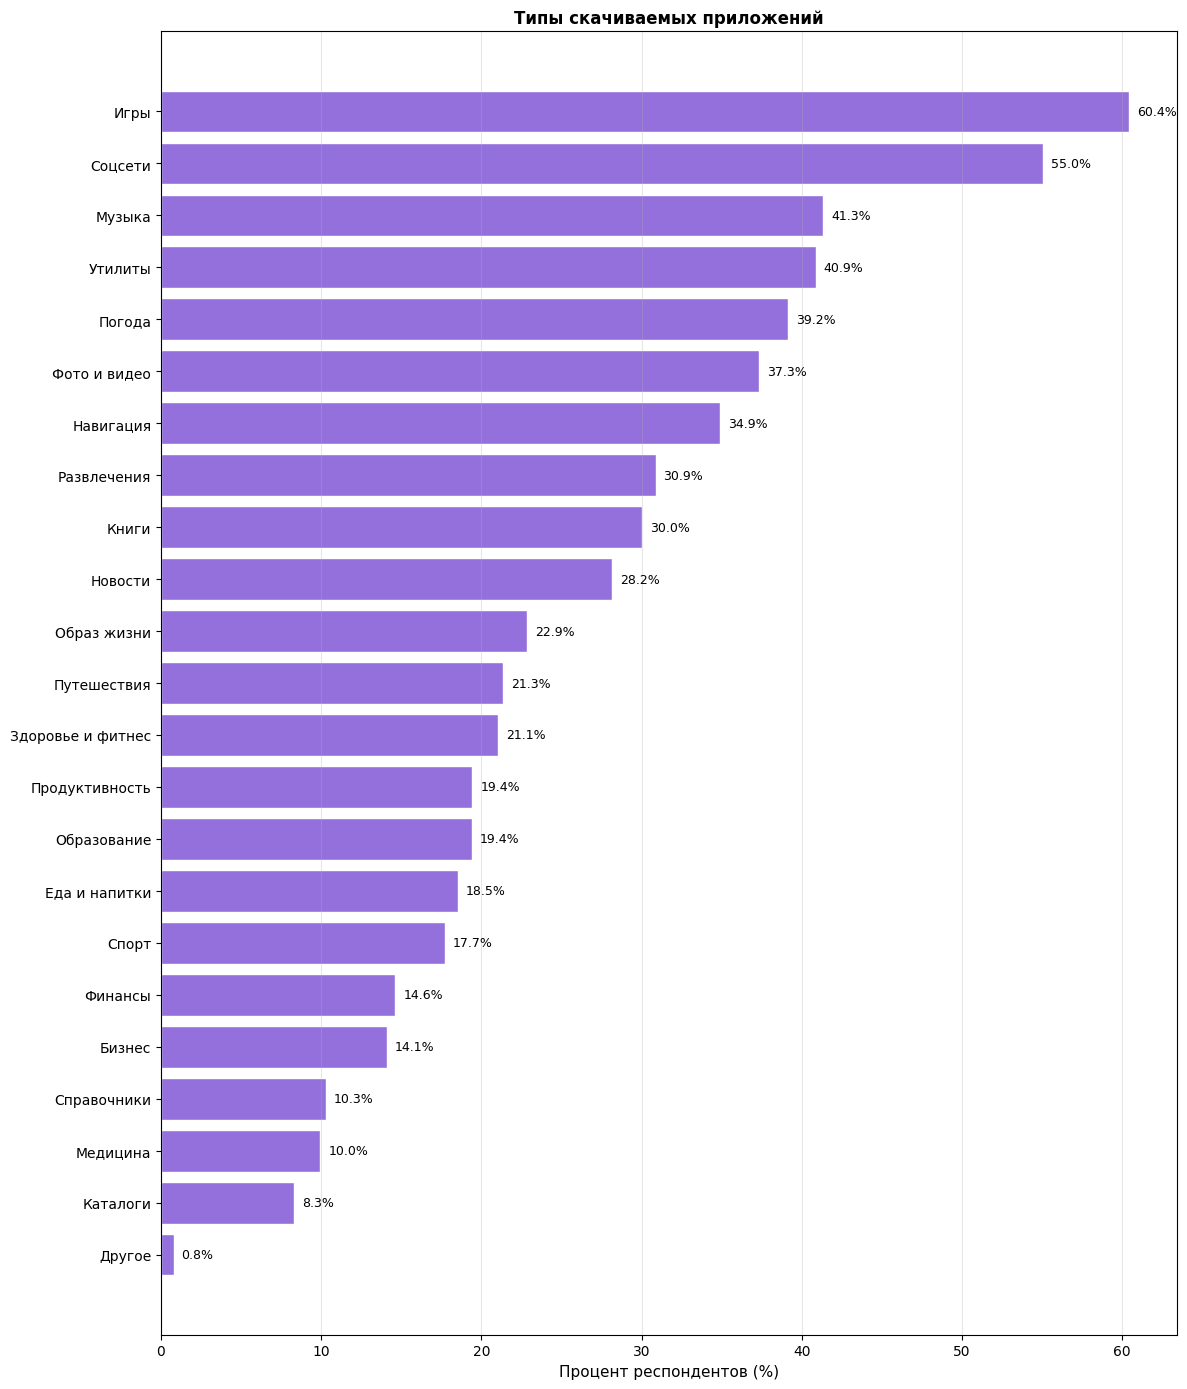

In [ ]:
plt.figure(figsize=(12, 14))
q15_percentages_sorted = q15_percentages.sort_values()
bars = plt.barh(q15_percentages_sorted.index, q15_percentages_sorted.values,
                color='mediumpurple', edgecolor='white', linewidth=1)
plt.xlabel('Процент респондентов (%)', fontsize=11)
plt.title('Типы скачиваемых приложений', fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for bar, pct in zip(bars, q15_percentages_sorted.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{pct:.1f}%', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

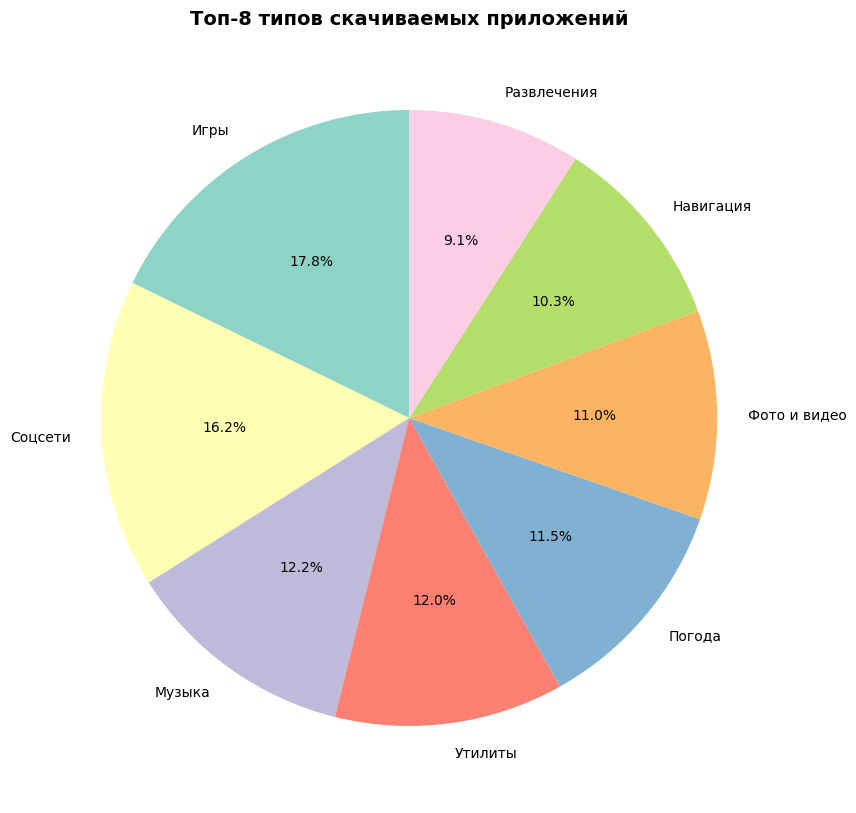

In [ ]:
plt.figure(figsize=(10, 10))
top8 = q15_counts.nlargest(8)
colors = plt.cm.Set3(range(len(top8)))
plt.pie(top8, labels=top8.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Топ-8 типов скачиваемых приложений', fontsize=14, fontweight='bold')
plt.show()

In [ ]:
most_popular = q15_counts.nlargest(3)
print("Самые популярные типы приложений:")
for app, count in most_popular.items():
    pct = (count / total_respondents) * 100
    print(f"  {app}: {pct:.1f}%")

# Развлекательные vs Утилитарные
entertainment = ['Игры', 'Развлечения', 'Музыка', 'Соцсети']
utilitarian = ['Утилиты', 'Продуктивность', 'Навигация', 'Погода']

entertainment_total = q15_counts[entertainment].sum()
utilitarian_total = q15_counts[utilitarian].sum()

print(f"\nРазвлекательные приложения: {entertainment_total/total_respondents*100:.1f}%")
print(f"Утилитарные приложения: {utilitarian_total/total_respondents*100:.1f}%")

Самые популярные типы приложений:
  Игры: 60.4%
  Соцсети: 55.0%
  Музыка: 41.3%

Развлекательные приложения: 187.6%
Утилитарные приложения: 134.3%


# Краткие итоги пользовательского поведения
1. Магазины приложений и устройства:

Основные устройства, которыми пользуются опрашиваемые это Samsung, Nokia, Apple, соответственно

Google Play — доминирующий магазин (~60-70%)

Apple App Store — второе место (~20-25%)

Остальные магазины (Samsung, Windows, Blackberry) занимают менее 5%

2. Частота посещения

Активные пользователи (раз в неделю и чаще): ~35-40%

Умеренные пользователи (раз в месяц): ~25-30%

Неактивные пользователи (реже раза в месяц): ~25-30%

Средняя частота — ближе к категории "раз в месяц"

3. Кол-во загрузок

Большинство пользователей загружают 2-5 приложений в месяц

Активные загрузчики (6-20 приложений) составляют ~20-25%

Среднее значение — около 8-10 приложений в месяц

Медиана — 3-5 приложений (большинство загружает мало)

4. Когда ищут приложения

Топ-3 причины:

Когда нужно выполнить задачу — самая популярная причина

Когда хочу развлечься — второе место

Когда нужно что-то узнать — третье место

Наименее популярно: "когда чувствую депрессию"

5. Как находят приложения

Топ-3 способа:

Поиск по ключевым словам — самый популярный способ

Сравнение нескольких приложений — осознанный подход

Смотрю топ загрузок — доверие к популярности

Наименее популярно: "скачиваю первое попавшееся" — пользователи редко выбирают импульсивно

6. Что учитывают при выборе

Топ-3 фактора:

Отзывы пользователей — самый важный фактор

Рейтинг (звезды) — второе место

Функции приложения — третье место

Наименее важно:

Размер приложения

Иконка

Разработчик

7. Почему скачивают

Топ-3 причины:

Выполнить задачу

Развлечение

Любопытство

8. Почему покупают

~40-50% пользователей не платят за приложения

Основные причины трат:

Убрать рекламу
Дополнительные функции
Скидка/распродажа

Платят ради качества: многие считают, что платные приложения лучше по качеству и функциональности

9. Почему ставят оценки

~35-40% пользователей не ставят оценки

Среди тех, кто ставит:

Сообщить, что приложение хорошее
Приложение попросило
Сообщить, что приложение плохое
Вознаграждение за оценку — наименее популярная причина

10. Почему перестают использовать

Топ-5 причин:

Нашел лучшее приложение — конкуренция

Больше не нужно — потеря потребности

Надоело — потеря интереса

Вылетает/зависает — технические проблемы

Раздражающая реклама — монетизация

Ключевой инсайт: технические проблемы и реклама — главные драйверы отказа

11. Типы скачиваемых приложений

Топ-5:

Игры — самый популярный тип (~60-70%)

Соцсети — второе место (~50-60%)

Утилиты — практические инструменты

Музыка — развлечение

Фото и видео — творчество

____
Пользователи сравнивают приложения, читают отзывы, ищут по ключевым словам

Основная мотивация — выполнение задач и развлечение

Главные барьеры — технические проблемы, навязчивая реклама, потеря интереса

Монетизация — большинство не платит, но готовы платить за отсутствие рекламы и дополнительные функции

Оценки — оставляют в основном для помощи другим, а не ради выгоды

Игры и соцсети — доминирующие категории приложений

Удержание пользователей — критически важно качество, стабильность работы и отсутствие раздражающей рекламы
___
Профиль типичного пользователя:

- Посещает магазин раз в месяц

- Загружает 2-5 приложений в месяц

- Тратит 0-5 у.е.

- Скачивает игры и соцсети

- Ищет приложения по ключевым словам и отзывам

- Перестает использовать из-за технических проблем или потери интереса

# Анализ профиля пользователя

## Возраст

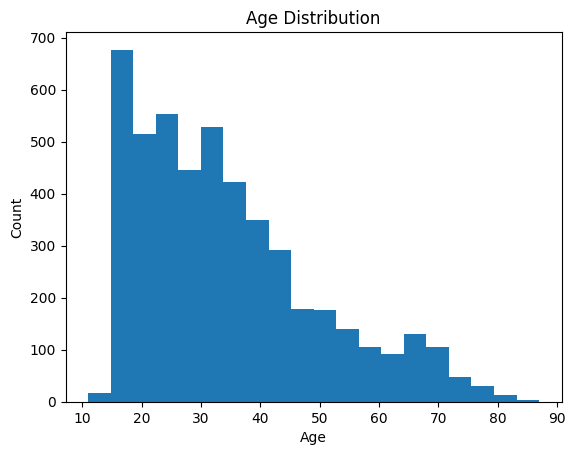

In [ ]:
df = df.rename(columns={"Q17": "Age"})

plt.hist(df["Age"].dropna(), bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Семейное положение

In [ ]:
mapping = {
    1: 'В отношениях',
    2: 'Свободен/свободна',
    3: 'Женат/замужем',
    4: 'Разведен(а)',
    5: 'Вдовец/вдова',
    6: 'В раздельном проживании',
    7: 'Другое'}

df['status'] = df['Q18'].map(mapping)
df['status'].value_counts()

,count
status,
Женат/замужем,2028
Свободен/свободна,1726
В отношениях,757
Разведен(а),177
В раздельном проживании,74
Вдовец/вдова,50
Другое,12


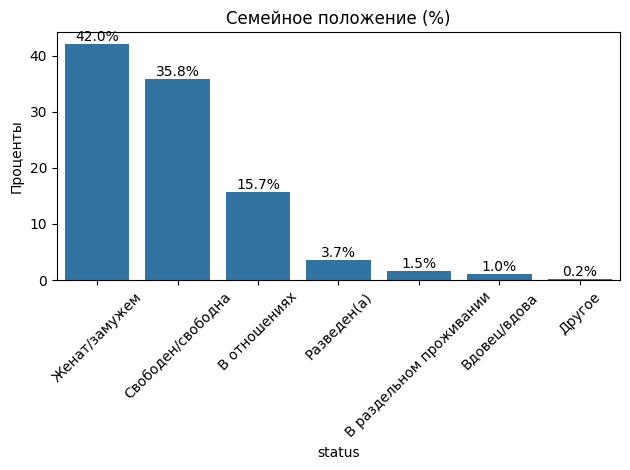

In [ ]:
counts = df['status'].value_counts(normalize=True) * 100

plt.figure()
ax = sns.barplot(x=counts.index, y=counts.values)

for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

plt.title('Семейное положение (%)')
plt.ylabel('Проценты')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Национальность

In [ ]:
mapping_en = {
    1: 'United States',
    2: 'Australia',
    3: 'Brazil',
    4: 'United Kingdom',
    5: 'Canada',
    6: 'China',
    7: 'France',
    8: 'Germany',
    9: 'India',
    10: 'Italy',
    11: 'Japan',
    12: 'Mexico',
    13: 'Russia',
    14: 'South Korea',
    15: 'Spain',
    16: 'Other'}

mapping_ru = {
    1: 'США',
    2: 'Австралия',
    3: 'Бразилия',
    4: 'Великобритания',
    5: 'Канада',
    6: 'Китай',
    7: 'Франция',
    8: 'Германия',
    9: 'Индия',
    10: 'Италия',
    11: 'Япония',
    12: 'Мексика',
    13: 'Россия',
    14: 'Южная Корея',
    15: 'Испания',
    16: 'Другое'}

df['country_en'] = df['Q19'].map(mapping_en)
df['country_ru'] = df['Q19'].map(mapping_ru)

In [ ]:
counts = df.groupby(['country_en', 'country_ru']).size().reset_index(name='count')

# убираем "Другое"
counts = counts[counts['country_en'] != 'Other']

In [ ]:
counts

,country_en,country_ru,count
0,Australia,Австралия,247
1,Brazil,Бразилия,428
2,Canada,Канада,426
3,China,Китай,557
4,France,Франция,233
5,Germany,Германия,250
6,India,Индия,365
7,Italy,Италия,266
8,Japan,Япония,214
9,Mexico,Мексика,245


In [ ]:
fig = px.choropleth(
    counts,
    locations="country_en",   # английские названия для plotly
    locationmode="country names",
    color="count",
    hover_name="country_ru",  # русские при наведении
    title="Распределение респондентов по странам")

fig.update_layout(geo=dict(showframe=False, showcoastlines=True))
fig.show()

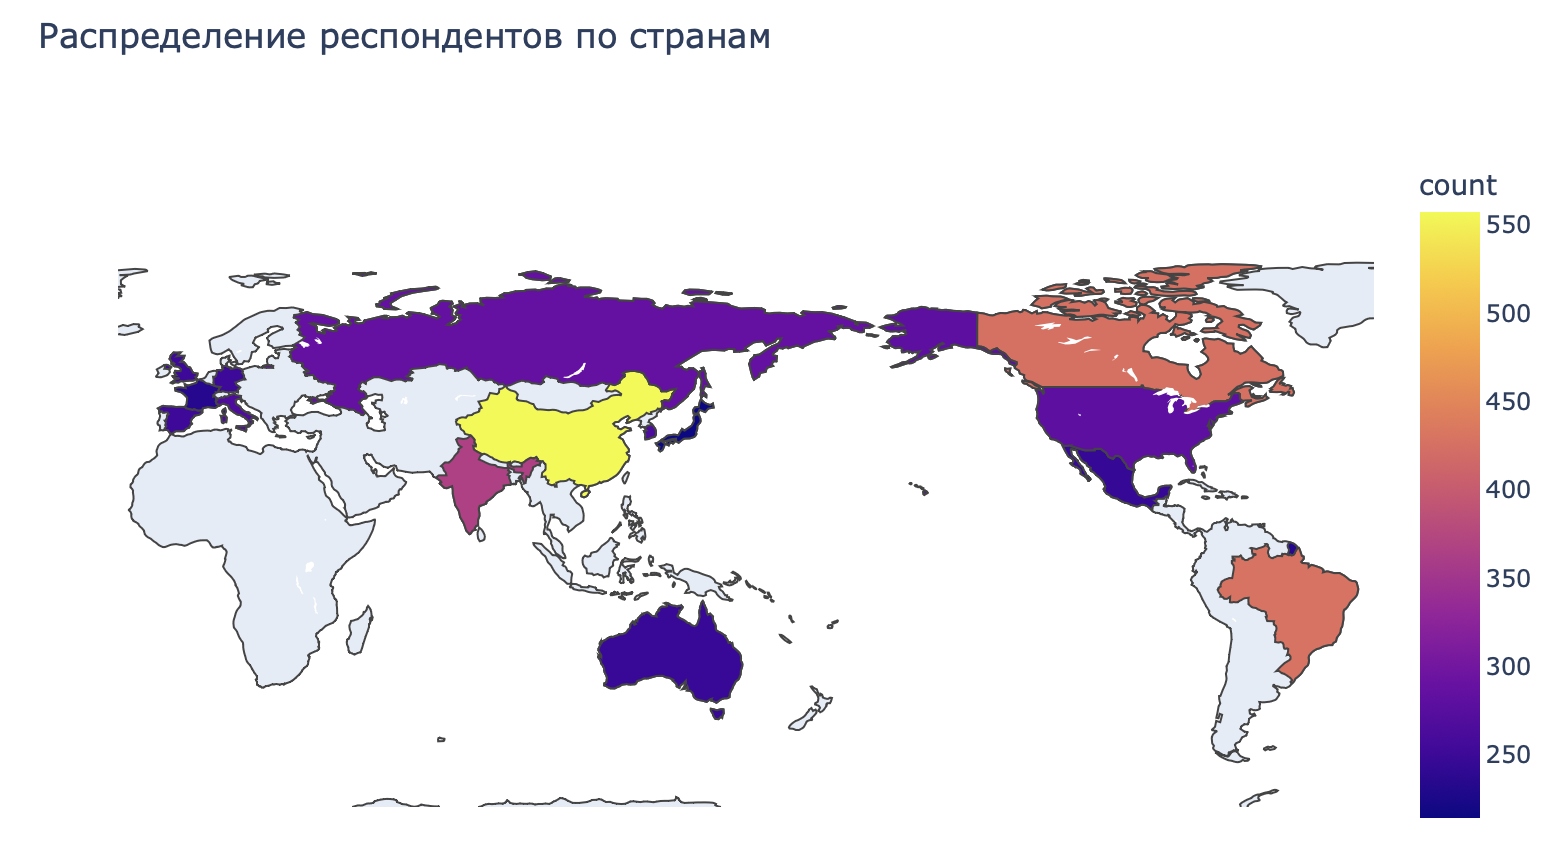

## Язык

In [ ]:
mapping_lang = {
    1: 'Английский',
    2: 'Французский',
    3: 'Немецкий',
    4: 'Итальянский',
    5: 'Японский',
    6: 'Корейский',
    7: 'Китайский',
    8: 'Португальский',
    9: 'Русский',
    10: 'Испанский',
    11: 'Другое'}

df['language_ru'] = df['Q21'].map(mapping_lang)

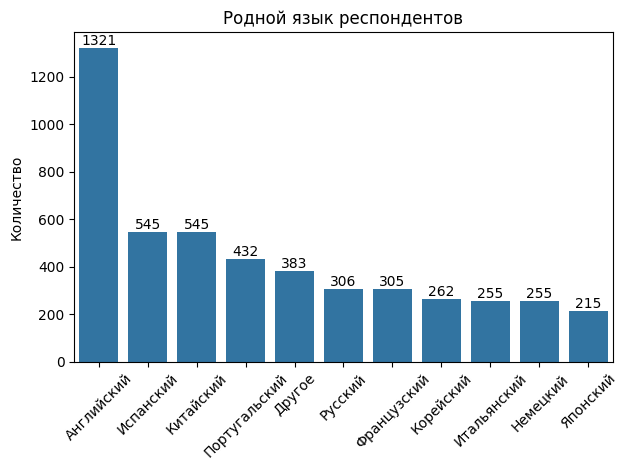

In [ ]:
counts = df['language_ru'].value_counts()

plt.figure()
ax = sns.barplot(x=counts.index, y=counts.values)

# подписи
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Родной язык респондентов')
plt.xlabel('')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Образование

In [ ]:
mapping_edu = {
    1: 'Начальное образование',
    2: 'Среднее образование',
    3: 'Диплом (колледж)',
    4: 'Профессиональное обучение',
    5: 'Бакалавриат',
    6: 'Магистратура',
    7: 'Аспирантура (PhD)',
    8: 'Другое'}

df['education'] = df['Q23'].map(mapping_edu)

In [ ]:
order = [
    'Начальное образование',
    'Среднее образование',
    'Диплом (колледж)',
    'Профессиональное обучение',
    'Бакалавриат',
    'Магистратура',
    'Аспирантура (PhD)',
    'Другое']

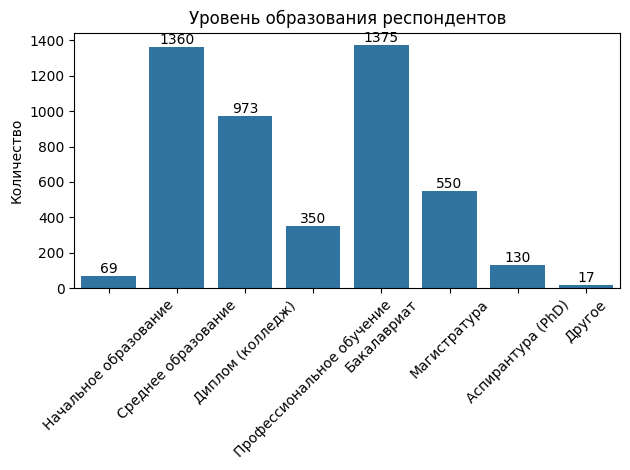

In [ ]:
plt.figure()
ax = sns.countplot(data=df, x='education', order=order)

# подписи
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.title('Уровень образования респондентов')
plt.xlabel('')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Занятость

In [ ]:
mapping_emp = {
    1: 'Полная занятость',
    2: 'Частичная занятость',
    3: 'Самозанятый',
    4: 'Студент',
    5: 'Домохозяйство',
    6: 'Безработный',
    7: 'Не может работать',
    8: 'Пенсионер',
    9: 'Другое'}

df['employment'] = df['Q26'].map(mapping_emp)

In [ ]:
order = [
    'Полная занятость',
    'Частичная занятость',
    'Самозанятый',
    'Студент',
    'Безработный',
    'Домохозяйство',
    'Пенсионер',
    'Не может работать',
    'Другое']

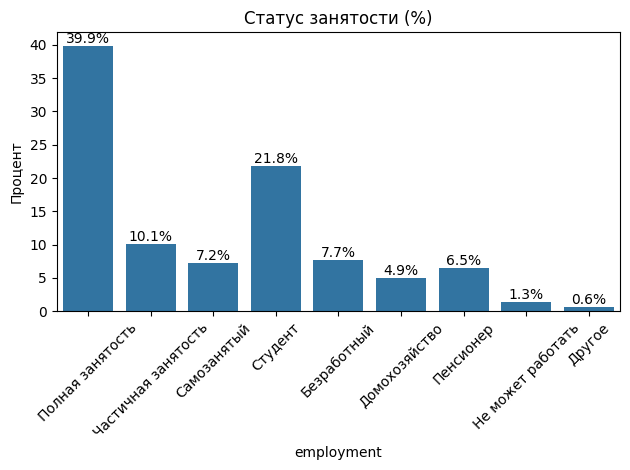

In [ ]:
counts = df['employment'].value_counts(normalize=True).reindex(order) * 100

plt.figure()
ax = sns.barplot(x=counts.index, y=counts.values)

for i, v in enumerate(counts.values):
    if not pd.isna(v):
        ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom')

plt.title('Статус занятости (%)')
plt.ylabel('Процент')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Валюта

In [ ]:
q29_mapping = {  'Q29.1': 'AUD',
                'Q29.2': 'BRL',
                'Q29.3': 'GBR',
                'Q29.4': 'Canadian Dollar',
                'Q29.5': 'CNY',
                'Q29.6': 'EUR',
                'Q29.7': 'INR',
                'Q29.8': 'JPY',
                'Q29.9': 'MXN',
                'Q29.10': 'RUB',
                'Q29.11': 'KRW',
                'Q29.12': 'USD'}

q29_counts = pd.Series({ru_name: df[col].sum()
                       for col, ru_name in q29_mapping.items()
                       if col in df.columns})

# Сортируем по убыванию
q29_counts = q29_counts.sort_values(ascending=False)
q29_counts

,0
EUR,5696
CNY,3770
Canadian Dollar,2920
INR,2266
BRL,1821
AUD,1737
GBR,1660
USD,1532
MXN,1404
JPY,1346


/tmp/ipykernel_2865/947633227.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




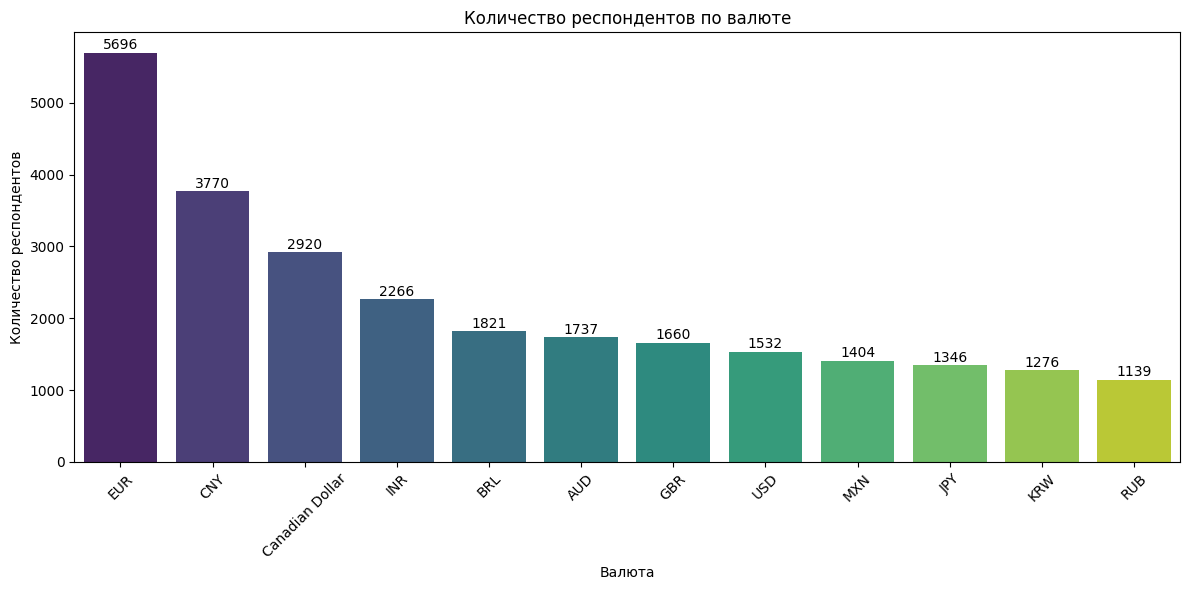

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(data=q29_counts, palette='viridis')

# подписи на барах
for i, v in enumerate(q29_counts):
    plt.text(i, v + 50, str(v), ha='center')

plt.title('Количество респондентов по валюте')
plt.xlabel('Валюта')
plt.ylabel('Количество респондентов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Тип личности

In [ ]:
q30_mapping = {
    'Q30_1': 'Экстравертный, энтузиаст',
    'Q30_2': 'Критичный, сварливый',
    'Q30_3': 'Надежный, дисциплинированный',
    'Q30_4': 'Тревожный, легко расстраивается',
    'Q30_5': 'Открытый новому, сложный',
    'Q30_6': 'Сдержанный, тихий',
    'Q30_7': 'Сочувствующий, теплый',
    'Q30_8': 'Неорганизованный, небрежный',
    'Q30_9': 'Спокойный, эмоционально стабильный',
    'Q30_10': 'Конвенциональный, некреативный'}

q30_counts = pd.Series({ru_name: df[col].sum()
                       for col, ru_name in q30_mapping.items()
                       if col in df.columns})

# Сортируем по убыванию
q30_counts = q30_counts.sort_values(ascending=False)
q30_counts

,0
"Надежный, дисциплинированный",26174
"Сочувствующий, теплый",26021
"Открытый новому, сложный",25472
"Спокойный, эмоционально стабильный",23895
"Экстравертный, энтузиаст",22086
"Сдержанный, тихий",21026
"Тревожный, легко расстраивается",16634
"Критичный, сварливый",16593
"Конвенциональный, некреативный",14854
"Неорганизованный, небрежный",13186


# Итоги анализа профиля пользователя

Большая часть опрашиваемых среднего возраста

Наиболее распространённый статус — «Женат/замужем» (2 028 человек). Это составляет около 42,5% от общей численности выборки (если считать сумму всех категорий ≈ 4 824).
Второй по популярности статус — «Свободен/свободна» (1 726 человек) — примерно 35,8%. Таким образом, почти 78% респондентов либо состоят в браке, либо никогда не состояли.

Лидеры по количеству респондентов:

* Китай — 557 человек (максимальное значение).
* Бразилия — 428 человек.
* Канада — 426 человек.

Эти три страны составляют почти 30% от общей выборки (если считать сумму всех представленных стран).
Страны со средними показателями (250–370 человек):

Индия (365), Россия (287), США (280), Италия (266), Южная Корея (264), Испания (251), Германия (250), Великобритания (250).
Россия (287) находится примерно в середине списка, чуть выше США (280).

Основной язык - английский (1321), далее испанский (545) и китайский (545).

Большинство респондентов имеют высшее образование — наибольшая доля приходится на бакалавриат (1375 человек) и среднее образование (1360 человек). Значительная часть также имеет диплом колледжа (973 человека).

Наибольшая доля респондентов имеет полную занятость (39,9%), что указывает на преобладание экономически активного населения. Второй по величине группой являются студенты (21,8%), что говорит о значительном присутствии молодежи в выборке.

Самая популярная валюта среди опрашиваемых - евро (5636), далее следует CNY (3770) и канадский доллар (2920)


# ИТОГИ

* Android доминирует (60–70%), iOS — второй по значимости сегмент
* Пользователи выбирают осознанно: ищут, читают отзывы, сравнивают
* Основная цель — решить задачу или развлечься

1. Монетизация и поведение

40–50% не платят за приложения. Платят за отключение рекламы или дополнительные функции

2. В среднем:

заходят раз в месяц, скачивают 2–5 приложений

3. Отток пользователей

Главные причины:
- нашли лучшее приложение
- потеряли интерес
- баги и зависания
- навязчивая реклама

> Ключевой фактор — качество продукта

4. Выбор приложений

Пользователи ориентируются на:
- отзывы
- рейтинг
- функциональность

> Импульсивные скачивания — редкость

Популярные категории

* Игры
* Социальные сети
* Утилиты

5. Портрет пользователя:
- Заходит в стор раз в месяц
- Скачивает 3–5 приложений
- Почти не платит
- Уходит при плохом UX или багах


___
**Главный инсайт**

Пользователь платит не за приложение, а за:
* удобство
* стабильность
* отсутствие раздражения




# Воронки

In [ ]:
base = df.copy()

# Шаги
step1 = len(base)

step2 = len(base[base['Do you use apps? (based on all app related questions)'] == 1])

step3 = len(base[(base['Do you use apps? (based on all app related questions)'] == 1) & (base["For those who answered Q4, do they know which app store they are using?"] == 1)])

step4 = len(base[(base["Do you use apps? (based on all app related questions)"] == 1) &
                 (base["For those who answered Q4, do they know which app store they are using?"] == 1) &
                 (base["Q5"] > 2)])

step5 = len(base[(base["Do you use apps? (based on all app related questions)"] == 1) &
                 (base["For those who answered Q4, do they know which app store they are using?"] == 1) &
                 (base["Q5"] > 2) &
                 (base["Q6"] > 1)])

# платящие
spend_cols = [col for col in df.columns if "Q11_" in col]
# все причины КРОМЕ "не плачу"
pay_reason_cols = [col for col in spend_cols if col != "Q11_1"]

base["Pays"] = ((df["Q11_1"] != 1) &  # не выбрал "не плачу"
                (df[pay_reason_cols].sum(axis=1) > 0))  # есть причины платить

step6 = len(base[(base["Do you use apps? (based on all app related questions)"] == 1) &
                 (base["For those who answered Q4, do they know which app store they are using?"] == 1) &
                 (base["Q5"] > 2) &
                 (base["Q6"] > 1) &
                 (base["Pays"] == True)])

funnel = [step1, step2, step3, step4, step5, step6]

labels = [
    "Есть устройство",
    "Используют приложения",
    "Знают App Store",
    "Посещают App Store",
    "Скачивают приложения",
    "Платят за приложения"]

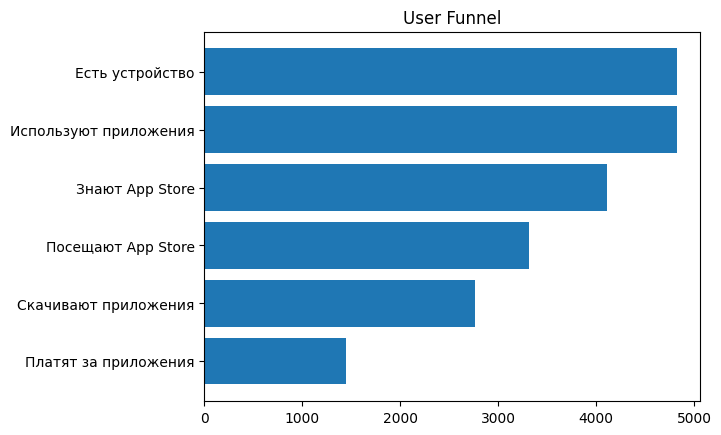

Есть устройство → Используют приложения: 100.00%
Используют приложения → Знают App Store: 85.12%
Знают App Store → Посещают App Store: 80.71%
Посещают App Store → Скачивают приложения: 83.34%
Скачивают приложения → Платят за приложения: 52.46%


In [ ]:
plt.figure()
plt.barh(labels, funnel)
plt.title("User Funnel")
plt.gca().invert_yaxis()
plt.show()

# конверсии
for i in range(len(funnel)-1):
    print(f"{labels[i]} → {labels[i+1]}: {funnel[i+1]/funnel[i]:.2%}")

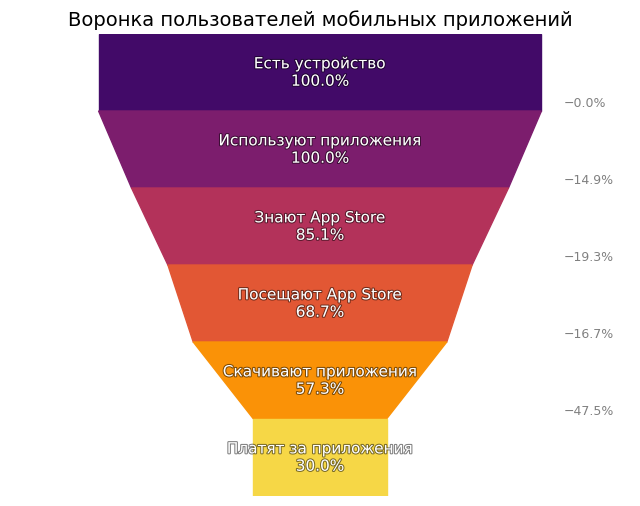

In [ ]:
values = funnel

# проценты от первого шага
percent = [v / values[0] * 100 for v in values]

# ширина воронки
widths = [p / max(percent) for p in percent]
fig, ax = plt.subplots(figsize=(8, 6))

# градиент
colors = plt.cm.inferno(np.linspace(0.2, 0.9, len(values)))

for i in range(len(values)):
    top = widths[i]
    bottom = widths[i+1] if i < len(values)-1 else widths[i]

    polygon = plt.Polygon([
        (-top/2, i),
        (top/2, i),
        (bottom/2, i+1),
        (-bottom/2, i+1)], color=colors[i])
    ax.add_patch(polygon)

    # основной текст
    ax.text(
        0, i + 0.5,
        f"{labels[i]}\n{percent[i]:.1f}%",
        ha='center',
        va='center',
        fontsize=11,
        color="white",
        path_effects=[pe.withStroke(linewidth=1.5, foreground="black", alpha=0.5)])

    # падение между этапами
    if i < len(values) - 1:
        conversion = percent[i+1] / percent[i] * 100
        drop = 100 - conversion

        ax.text(
            0.55, i + 0.9,
            f"−{drop:.1f}%",
            ha='left',
            va='center',
            fontsize=9,
            color="gray")

# убираем оси
ax.axis('off')
plt.title("Воронка пользователей мобильных приложений", fontsize=14)

plt.ylim(len(values), 0)
plt.xlim(-0.7, 0.7)

plt.show()

Ключевые выводы
1. Основной отток — ~15% пользователей не знают/не используют App Store
→ потеря на самом раннем этапе
2. Высокая конверсия внутри стора, 80%+ пользователей:
заходят
скачивают
→ стор работает эффективно как канал
3. Самый слабый этап — монетизация. Только ~52% платят
→ почти половина пользователей:
остаются в free-сегменте
4. “Узкое место” воронки. Главная проблема не в установках, а в конверсии в оплату
___
ИТОГ

- Воронка сильная до установки
- Основной рост — в монетизации и увеличении знания/доверия к сторам

Рекомендации:

→ Усиливать монетизацию

→ Работать с ранним этапом awareness

→ Не фокусироваться только на установках — там уже высокая конверсия